# First Exercise - Business Process Simulation, Prediction and Optimsation
### Data and Process Science on the BPIC-17 Event Log

#### Imports and Setup

In [290]:
import pm4py as pm
import pandas as pd
import helper
# import matplotlib.pyplot as plt

In [292]:
from importlib import reload

In [293]:
# Separate file to hide complexity of the methods
reload(helper)
h = helper.Helper()

In [275]:
# Open eventlog and load into dataframe to use for analyses
log = pm.read_xes("./data/BPI Challenge 2017.xes.gz")
df = pm.convert_to_dataframe(log)

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [ ]:
# Generate csv file to analyse different applications directly in the log
csv = df.to_csv("./data/BPI Challenge 2017.csv")

## Basic Analysis

### Initial overview

In [6]:
df.head(10)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Obtained,User_17,W_Complete application,Workflow,Workitem_1875340971,start,2016-01-02 10:45:22.429000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Released,User_17,W_Complete application,Workflow,Workitem_1452291795,suspend,2016-01-02 10:49:28.816000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,NaN


Get overview over different columns and their values

In [7]:
h.show_overview_table(df, sample_size=25)

,Activity,Unique Values,Data Type,Elements not null,Sample values
0,Action,5,object,1202267,"[Created, statechange, Deleted, Obtained, Released]"
1,org:resource,149,object,1202267,"[User_1, User_17, User_52, User_11, User_117, User_115, User_2, User_38, User_119, User_30, User_68, User_19, User_116, User_101, User_34, User_31, User_90, User_89, User_15, User_16, User_12, User_3, User_102, User_114, User_118]"
2,concept:name,26,object,1202267,"[A_Create Application, A_Submitted, W_Handle leads, W_Complete application, A_Concept, A_Accepted, O_Create Offer, O_Created, O_Sent (mail and online), W_Call after offers, A_Complete, W_Validate application, A_Validating, O_Returned, W_Call incomplete files, A_Incomplete, O_Accepted, A_Pending, A_Denied, O_Refused, O_Cancelled, A_Cancelled, O_Sent (online only), W_Assess potential fraud, W_Personal Loan collection]"
3,EventOrigin,3,object,1202267,"[Application, Workflow, Offer]"
4,EventID,1202267,object,1202267,"[Application_652823628, ApplState_1582051990, Workitem_1298499574, Workitem_1673366067, Workitem_1493664571, ApplState_642383566, Workitem_1875340971, Workitem_1452291795, ApplState_99568828, Offer_148581083, OfferState_1514834199, OfferState_2051164740, Workitem_1007505836, Workitem_1087320491, Workitem_719909876, ApplState_946455804, Workitem_1447720177, Workitem_1260329040, Workitem_1152103512, Workitem_524990185, Workitem_781654767, Workitem_1641716416, ApplState_752879093, OfferState_1310330551, Workitem_823786158]"
5,lifecycle:transition,7,object,1202267,"[complete, schedule, withdraw, start, suspend, ate_abort, resume]"
6,time:timestamp,1202209,"datetime64[ns, UTC]",1202267,"[2016-01-01 09:51:15.304000+00:00, 2016-01-01 09:51:15.352000+00:00, 2016-01-01 09:51:15.774000+00:00, 2016-01-01 09:52:36.392000+00:00, 2016-01-01 09:52:36.403000+00:00, 2016-01-01 09:52:36.413000+00:00, 2016-01-02 10:45:22.429000+00:00, 2016-01-02 10:49:28.816000+00:00, 2016-01-02 11:23:04.299000+00:00, 2016-01-02 11:29:03.994000+00:00, 2016-01-02 11:29:05.354000+00:00, 2016-01-02 11:30:28.606000+00:00, 2016-01-02 11:30:28.621000+00:00, 2016-01-02 11:30:28.629000+00:00, 2016-01-02 11:30:28.631000+00:00, 2016-01-02 11:30:28.633000+00:00, 2016-01-02 11:32:41.624000+00:00, 2016-01-06 09:26:44.492000+00:00, 2016-01-06 09:27:08.472000+00:00, 2016-01-13 13:10:55.138000+00:00, 2016-01-13 13:10:55.144000+00:00, 2016-01-13 13:10:55.145000+00:00, 2016-01-13 13:10:55.973000+00:00, 2016-01-13 13:11:03.569000+00:00, 2016-01-13 13:15:39.110000+00:00]"
7,case:LoanGoal,14,object,1202267,"[Existing loan takeover, Home improvement, Car, Other, see explanation, Remaining debt home, Not speficied, Unknown, Caravan / Camper, Tax payments, Extra spending limit, Motorcycle, Boat, Business goal, Debt restructuring]"
8,case:ApplicationType,2,object,1202267,"[New credit, Limit raise]"
9,case:concept:name,31509,object,1202267,"[Application_652823628, Application_1691306052, Application_428409768, Application_1746793196, Application_828200680, Application_1085880569, Application_1266995739, Application_1878239836, Application_619403287, Application_1710223761, Application_1529124572, Application_387012864, Application_1120819670, Application_42838382, Application_180547487, Application_1966208034, Application_1806387393, Application_1111870538, Application_1017492916, Application_2082119944, Application_758985626, Application_1018615109, Application_319587802, Application_1846626914, Application_546206358]"


- ID columns (unique): users, events, cases, offers
- possible classifications: concepts, eventorigins, loangoals, application types
- business metrics: requested amount, first withdrawal amount, num of terms, monthly cost, credit score, offered amount
- flags (accepted, selected) and timestamps

Check for overlaps in transitions and actions column

In [8]:
pd.crosstab(df['Action'], df['lifecycle:transition'], margins=True, margins_name="Total")   # TODO format prettier

lifecycle:transition,ate_abort,complete,resume,schedule,start,suspend,withdraw,Total
Action,,,,,,,,
Created,0,74504,0,149104,0,0,0,223608
Deleted,85224,41862,0,0,0,0,21844,148930
Obtained,0,0,127160,0,128227,0,0,255387
Released,0,0,0,0,0,215402,0,215402
statechange,0,358940,0,0,0,0,0,358940
Total,85224,475306,127160,149104,128227,215402,21844,1202267


View start and end activities

In [270]:
pm.get_start_activities(log)

{'A_Create Application': 31509}

In [10]:
pm.get_end_activities(log)

{'W_Validate application': 12662,
 'O_Cancelled': 4436,
 'W_Call after offers': 9457,
 'W_Call incomplete files': 4676,
 'W_Complete application': 144,
 'W_Assess potential fraud': 102,
 'W_Personal Loan collection': 2,
 'W_Shortened completion ': 5,
 'A_Denied': 1,
 'O_Sent (online only)': 8,
 'O_Sent (mail and online)': 15,
 'O_Returned': 1}

- Validate application as end state doesn't make sense --> further analysis necessary using timestamps
- Calls as end activities don't make sense either

Analyse states of different end events

In [22]:
# Extract row data from different cases and their end events
df_sorted = df.sort_values(["case:concept:name", "time:timestamp"])
end_events = df_sorted.groupby("case:concept:name").tail(1)
end_events.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
686079,Deleted,User_1,W_Call after offers,Workflow,Workitem_1074507345,ate_abort,2016-09-05 06:00:36.893000+00:00,"Other, see explanation",New credit,Application_1000086665,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
445763,Deleted,User_90,W_Validate application,Workflow,Workitem_408959839,ate_abort,2016-06-10 11:02:01.282000+00:00,Home improvement,New credit,Application_1000158214,12500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279683,Deleted,User_1,W_Call after offers,Workflow,Workitem_1728373040,ate_abort,2016-05-05 06:00:48.963000+00:00,Car,New credit,Application_1000311556,45000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
841694,Deleted,User_68,W_Validate application,Workflow,Workitem_315515737,ate_abort,2016-09-29 07:45:34.389000+00:00,"Other, see explanation",New credit,Application_1000334415,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229687,Deleted,User_87,W_Validate application,Workflow,Workitem_784695087,ate_abort,2016-03-30 09:11:48.600000+00:00,Existing loan takeover,New credit,Application_1000339879,37500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_sorted.groupby("case:concept:name").tail(1)["Action"].value_counts()

Action
Deleted        26968
statechange     4461
Released          49
Created           31
Name: count, dtype: int64

Application and Offer time periods

In [24]:
h.show_timeline_table(df)

,Event Origin,Start date,End date
0,Application,2016-01-01 09:51:15.304000+00:00,2016-12-31 21:37:53.216000+00:00
1,Offer,2016-01-02 09:17:05.720000+00:00,2017-02-01 11:23:02.167000+00:00


- offers adressed until 2017
- applications only until the end of 2016

### Event log statistics

#### Simple metrics

Number of cases

In [25]:
df['case:concept:name'].nunique()

31509

Number of events

In [26]:
len(log)

1202267

Number of process variants

In [27]:
len(pm.get_variants(log))

15930

Number of case and event labels

In [28]:
print("Case labels: ", len(df['case:concept:name'].unique()))
print("Event labels: ", len(df['concept:name'].unique()))

Case labels:  31509
Event labels:  26


Number of categorical event attributes

In [29]:
len(pm.get_event_attributes(log))

19

Mean and standard deviation of case length

In [30]:
caselengths = df.groupby('case:concept:name').size()
print("Mean: ", caselengths.mean())
print("Standard deviation: ", caselengths.std())

Mean:  38.15630454790695
Standard deviation:  16.71530805656448


Mean and standard deviations of case duration

In [31]:
casedurations = pd.Series(pm.get_all_case_durations(log))

In [32]:
print("Mean: ", pd.Timedelta(casedurations.mean(), unit='s'))
print("Mean in seconds: ", casedurations.mean())
print("Mean in minutes: ", casedurations.mean() / 60)
print("Mean in hours: ", casedurations.mean() / 60 / 60)
print("Mean in days: ", casedurations.mean() / 60 / 60 / 24)


Mean:  21 days 21:35:25.923069948
Mean in seconds:  1892125.923069948
Mean in minutes:  31535.4320511658
Mean in hours:  525.5905341860966
Mean in days:  21.89960559108736


In [33]:
print("Standard deviation: ", pd.Timedelta(casedurations.std(), unit='s'))
print("Standard deviation in seconds: ", casedurations.std())
print("Standard deviation in minutes: ", casedurations.std() / 60)
print("Standard deviation in hours: ", casedurations.std() / 60 / 60)
print("Standard deviation in days: ", casedurations.std() / 60 / 60 / 24)

Standard deviation:  13 days 04:03:41.690875764
Standard deviation in seconds:  1137821.6908757635
Standard deviation in minutes:  18963.694847929393
Standard deviation in hours:  316.06158079882323
Standard deviation in days:  13.169232533284301


Mean and standard deviation of loan related columns

In [39]:
loan_metrics = df.groupby(['case:concept:name']).agg(
    RequestedAmount = ('case:RequestedAmount', 'last'),
    OfferedAmount=('OfferedAmount', 'last'),
    FirstWithdrawalAmount=('FirstWithdrawalAmount', 'last'),
    MonthlyCost=('MonthlyCost', 'last'),
    NumberOfTerms= ('NumberOfTerms', 'last'),
    CreditScore=('CreditScore', 'last')
)
loan_metrics.describe()

,RequestedAmount,OfferedAmount,FirstWithdrawalAmount,MonthlyCost,NumberOfTerms,CreditScore
count,31509.000000,31509.000000,31509.000000,31509.000000,31509.000000,31509.000000
mean,16233.743989,18117.660461,8165.483469,275.854643,82.729474,402.436828
std,15422.246299,13495.302503,10535.755908,183.260409,36.559262,451.701709
min,0.000000,5000.000000,0.000000,43.050000,6.000000,0.000000
25%,6000.000000,8000.000000,0.000000,150.090000,56.000000,0.000000
50%,12500.000000,15000.000000,5000.000000,236.830000,77.000000,0.000000
75%,21000.000000,25000.000000,11500.000000,346.200000,120.000000,890.000000
max,450000.000000,75000.000000,75000.000000,3260.920000,180.000000,1145.000000


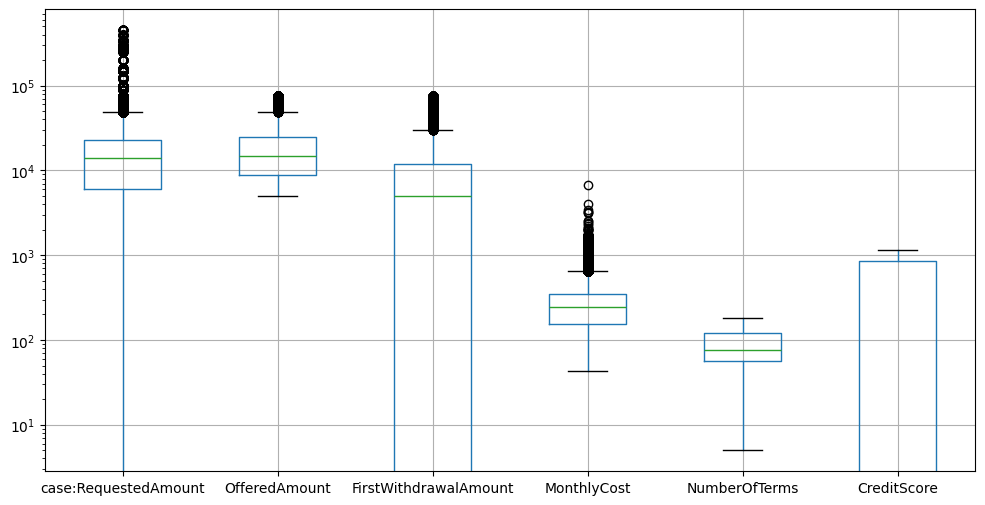

In [40]:
# Plot previous results
plt.figure(figsize=(12,6))
df[["case:RequestedAmount", "OfferedAmount", "FirstWithdrawalAmount",
    "MonthlyCost", "NumberOfTerms", "CreditScore"]].boxplot()

plt.yscale("log")
plt.grid(True)
plt.show()

- private loans (5.000 - 75.000)
- avg. 280,- monthly cost

#### Additional metrics

Activity occurences

In [41]:
h.calculate_frequency_table(df, 'concept:name')

,Name,Count,Percentage,Cumulative
0,W_Validate application,209496,17.425%,17.425%
1,W_Call after offers,191092,15.894%,33.319%
2,W_Call incomplete files,168529,14.018%,47.337%
3,W_Complete application,148900,12.385%,59.722%
4,W_Handle leads,47264,3.931%,63.653%
5,O_Create Offer,42995,3.576%,67.229%
6,O_Created,42995,3.576%,70.805%
7,O_Sent (mail and online),39707,3.303%,74.108%
8,A_Validating,38816,3.229%,77.337%
9,A_Create Application,31509,2.621%,79.958%


- 5 Workflow events make up over 60% of the log
- activities 22-25 < 0.5% of whole log --> ignore for initial bpmn model

Activities in cases

In [42]:
df.groupby(["case:concept:name", "concept:name"]).first().reset_index()["concept:name"].value_counts()  # TODO Table

concept:name
A_Accepted                    31509
A_Concept                     31509
A_Create Application          31509
O_Create Offer                31509
O_Created                     31509
W_Complete application        31509
A_Complete                    31362
W_Call after offers           31362
O_Sent (mail and online)      31050
W_Validate application        21870
A_Validating                  21870
O_Returned                    21768
A_Submitted                   20423
W_Handle leads                20423
O_Accepted                    17228
A_Pending                     17228
O_Cancelled                   15682
A_Incomplete                  15003
W_Call incomplete files       15003
A_Cancelled                   10431
A_Denied                       3752
O_Refused                      3720
O_Sent (online only)           1800
W_Assess potential fraud        303
W_Shortened completion           74
W_Personal Loan collection        2
Name: count, dtype: int64

- all applications get an offer and are completed
- different names for states of activities (accepted, cancelled, denied) and offers (cancelled, accepted, refused) --> probably different names for bank and customer
- offers have at least one call
- bank only accepts 50% of their own offers (A_Pending/O_Create Offer => 54,67%)
- bank rejects 10% of their offers (A_Denied/O_Create Offer => 11,90%)
- customers reject around 33% of offers (A_Cancelled / O_Create Offer => 33,10%)
- almost 50% of customers submit incomplete files (Files / A_Accepted => 47,61%)

Loan Goal distribution

In [43]:
h.calculate_frequency_table(df, 'case:LoanGoal')

,Name,Count,Percentage,Cumulative
0,Car,339798,28.263%,28.263%
1,Home improvement,294389,24.486%,52.749%
2,Existing loan takeover,227606,18.931%,71.681%
3,"Other, see explanation",110643,9.203%,80.884%
4,Unknown,85085,7.077%,87.961%
5,Remaining debt home,43874,3.649%,91.610%
6,Not speficied,41048,3.414%,95.024%
7,Extra spending limit,22964,1.910%,96.934%
8,Caravan / Camper,12967,1.079%,98.013%
9,Motorcycle,9983,0.830%,98.843%


- three main loangoal types: Car, Home, Takeover

#### LEAVE OUT? Distribution plotting

taken from pm4py-source/notebooks/5_advanced_examples.ipynb

##### Events

Events per day

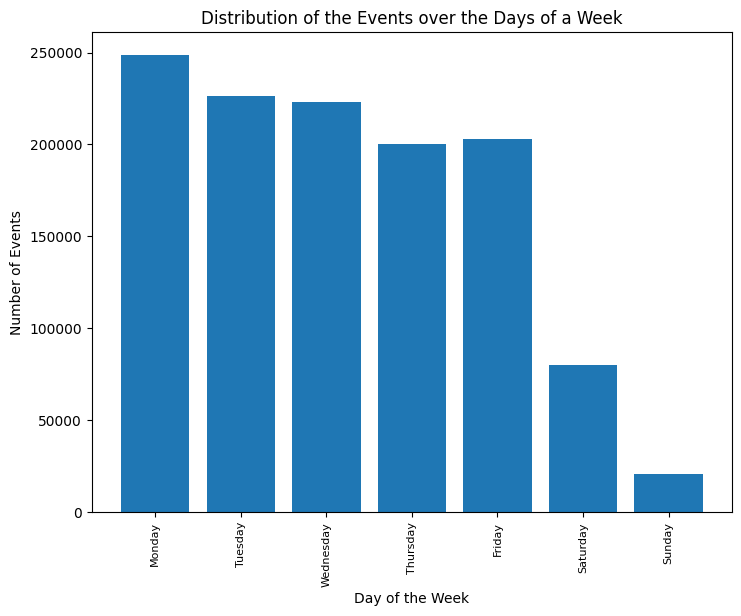

In [46]:
pm.view_events_distribution_graph(df, distr_type="days_week")

Events per hour

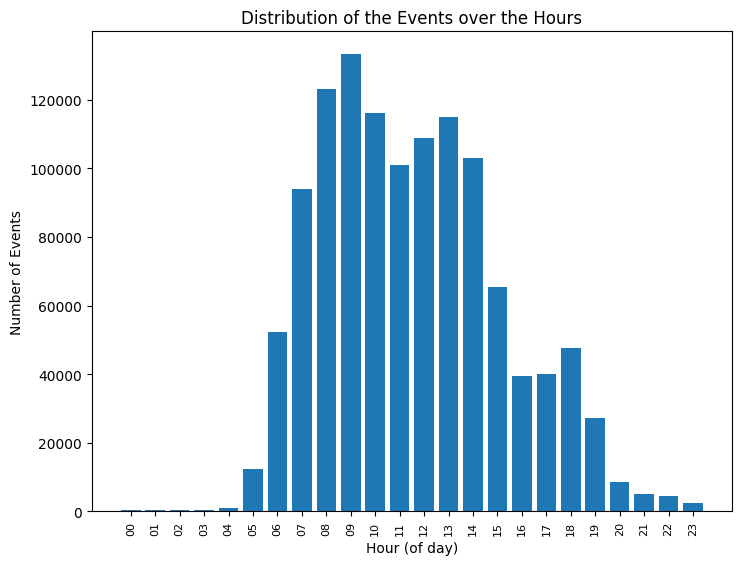

In [47]:
pm.view_events_distribution_graph(df, distr_type="hours")

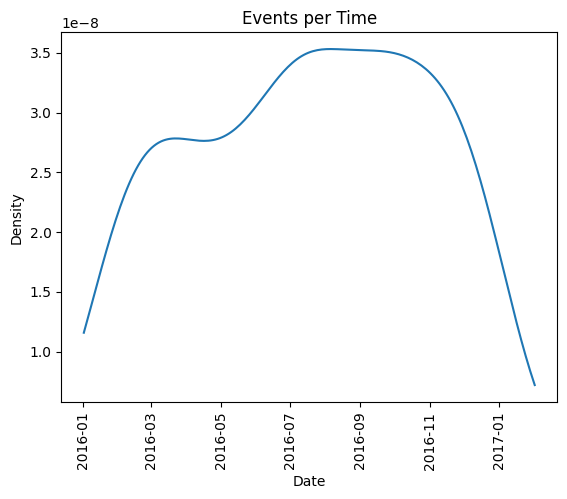

In [49]:
pm.view_events_per_time_graph(log)

##### Cases

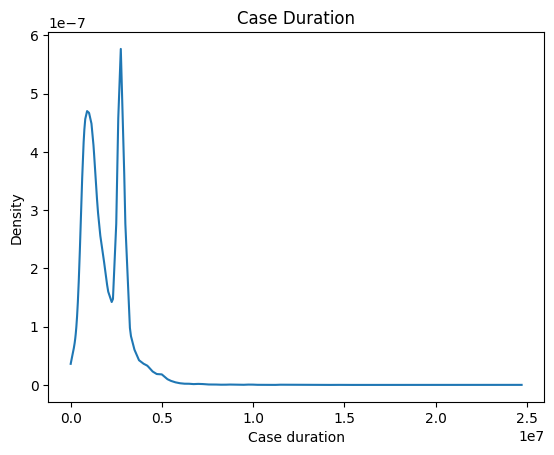

In [50]:
pm.view_case_duration_graph(log)

## Process Model Creation

### Filter eventlog

- Paramter 1: Removing/Adding activities
- Paramter 2: Removing/Adding Action states

Remove events that make up less than 0.5% of the event log

In [57]:
df_filtered = df[~df['concept:name'].isin(['W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection', 'O_Sent (online only)'])] # df_filtered_1, df_filtered_2
#df_filtered = df[~df['concept:name'].isin(['W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection'])]   # df_filtered_3
len(df_filtered)

1196699

Build workflow gradually based on previous analysis

In [58]:
df_filtered = df_filtered[df_filtered['Action'].isin(['Created', 'statechange'])]   # df_filtered_1 only included ['Created', 'statechange'], df_filtered_2 and 3 added ['Obtained']
# df_filtered_4 = ['Created', 'statechange', 'Released', 'Deleted']
len(df_filtered)

580119

Check occurences of events (Test)

In [62]:
test_log = pm.filter_between(df_filtered, 'A_Denied', 'O_Refused')
#test_log = df_filtered[df_filtered['concept:name'].isin(['W_Complete application', 'A_Accepted'])]
test_log.head(20)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
68,statechange,User_68,A_Denied,Application,ApplState_1181660825,complete,2016-01-07 13:29:49.671000+00:00,Home improvement,New credit,Application_1691306052##@@0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,statechange,User_68,O_Refused,Offer,OfferState_1494429296,complete,2016-01-07 13:29:49.710000+00:00,Home improvement,New credit,Application_1691306052##@@0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1669071500
328,statechange,User_99,A_Denied,Application,ApplState_427425012,complete,2016-01-11 09:30:52.964000+00:00,Home improvement,New credit,Application_1878239836##@@0,15000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329,statechange,User_99,O_Refused,Offer,OfferState_722957562,complete,2016-01-11 09:30:52.996000+00:00,Home improvement,New credit,Application_1878239836##@@0,15000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_117620760
644,statechange,User_95,A_Denied,Application,ApplState_1903278816,complete,2016-01-11 13:19:39.053000+00:00,Car,New credit,Application_1806387393##@@0,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
645,statechange,User_95,O_Refused,Offer,OfferState_130777715,complete,2016-01-11 13:19:39.082000+00:00,Car,New credit,Application_1806387393##@@0,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1690361215
842,statechange,User_29,A_Denied,Application,ApplState_1797042019,complete,2016-01-25 10:13:22.096000+00:00,Car,New credit,Application_319587802##@@0,7000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
843,statechange,User_29,O_Refused,Offer,OfferState_727662319,complete,2016-01-25 10:13:22.147000+00:00,Car,New credit,Application_319587802##@@0,7000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1377685007
909,statechange,User_90,A_Denied,Application,ApplState_365666003,complete,2016-01-11 09:39:35.053000+00:00,Home improvement,New credit,Application_546206358##@@0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
910,statechange,User_90,O_Refused,Offer,OfferState_295786467,complete,2016-01-11 09:39:35.166000+00:00,Home improvement,New credit,Application_546206358##@@0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_603196958


In [64]:
v = pm.filter_variants_top_k(df, 3)
#v.style

### Process Discovery

#### Inductive Miner

##### Baseline models

In [65]:
# Discover original bpmn model
ind_bpmn = pm.discover_bpmn_inductive(log)

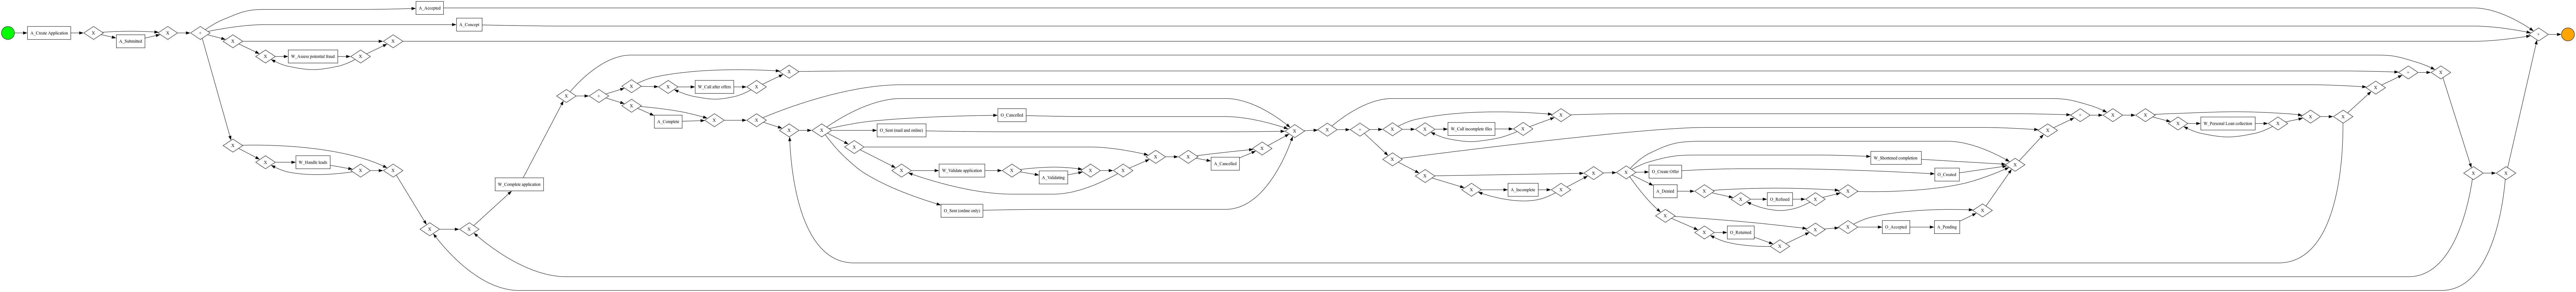

In [66]:
pm.view_bpmn(ind_bpmn)

In [67]:
# Convert to petri net
ind_petri, ind_im, ind_fm = pm.convert_to_petri_net(ind_bpmn)

##### Filtered models

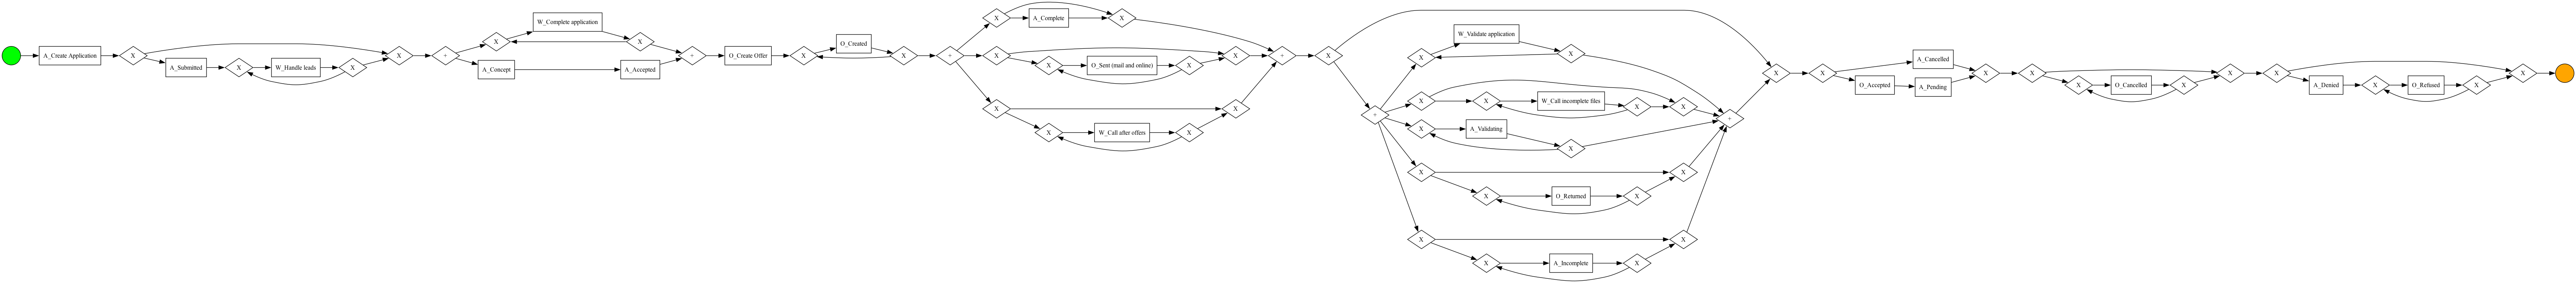

In [68]:
# Filter bpmn model to derive information for own model
ind_bpmn_filtered = pm.discover_bpmn_inductive(df_filtered, noise_threshold=0.2)
pm.view_bpmn(ind_bpmn_filtered)

#### Heuristic Miner

##### Baseline Models

In [69]:
# Discover Heuristic net with dependency threshold of 0%
heu_net = pm.discover_heuristics_net(log, dependency_threshold=0.0, and_threshold=0.0, loop_two_threshold=0.0)
heu_net_th = pm.discover_heuristics_net(log)    # default thresholds

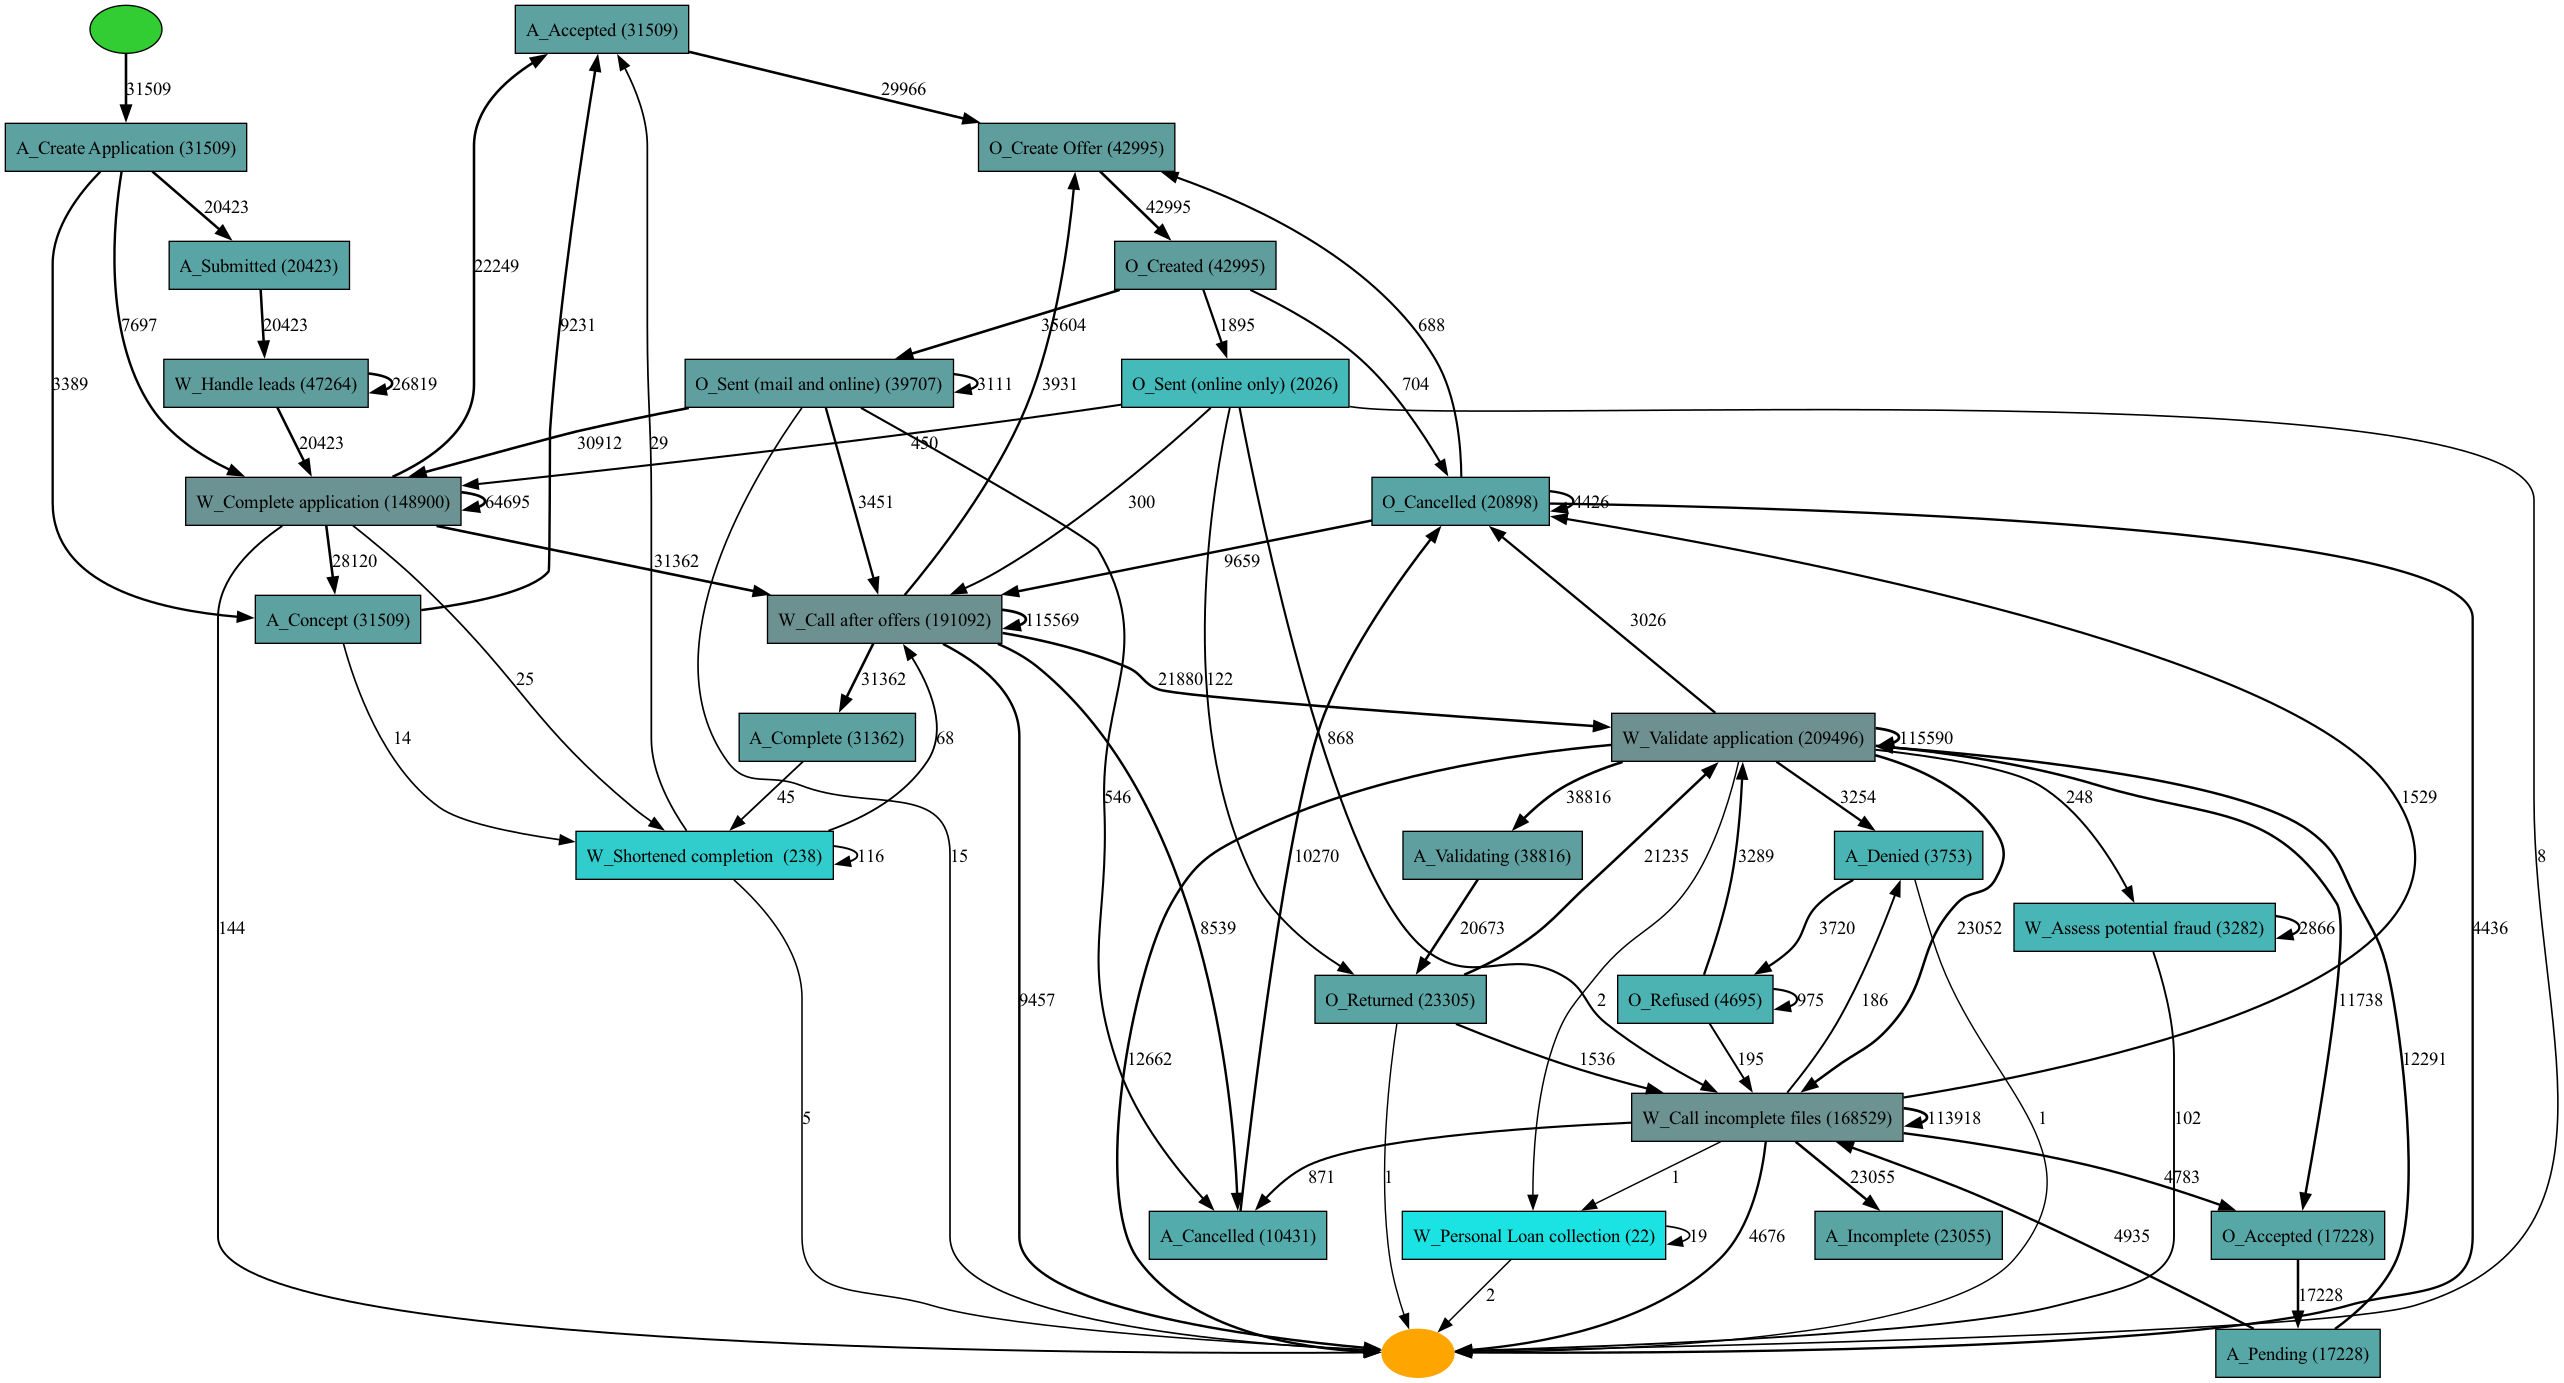

In [72]:
pm.view_heuristics_net(heu_net)

In [70]:
# Convert to bpmn model
heu_bpmn = pm.convert_to_bpmn(heu_net)
heu_bpmn_th = pm.convert_to_bpmn(heu_net_th)

In [71]:
# Convert to petri net
heu_petri, heu_im, heu_fm = pm.convert_to_petri_net(heu_net)
heu_petri_th, heu_im_th, heu_fm_th = pm.convert_to_petri_net(heu_net_th)

##### Filtered Log

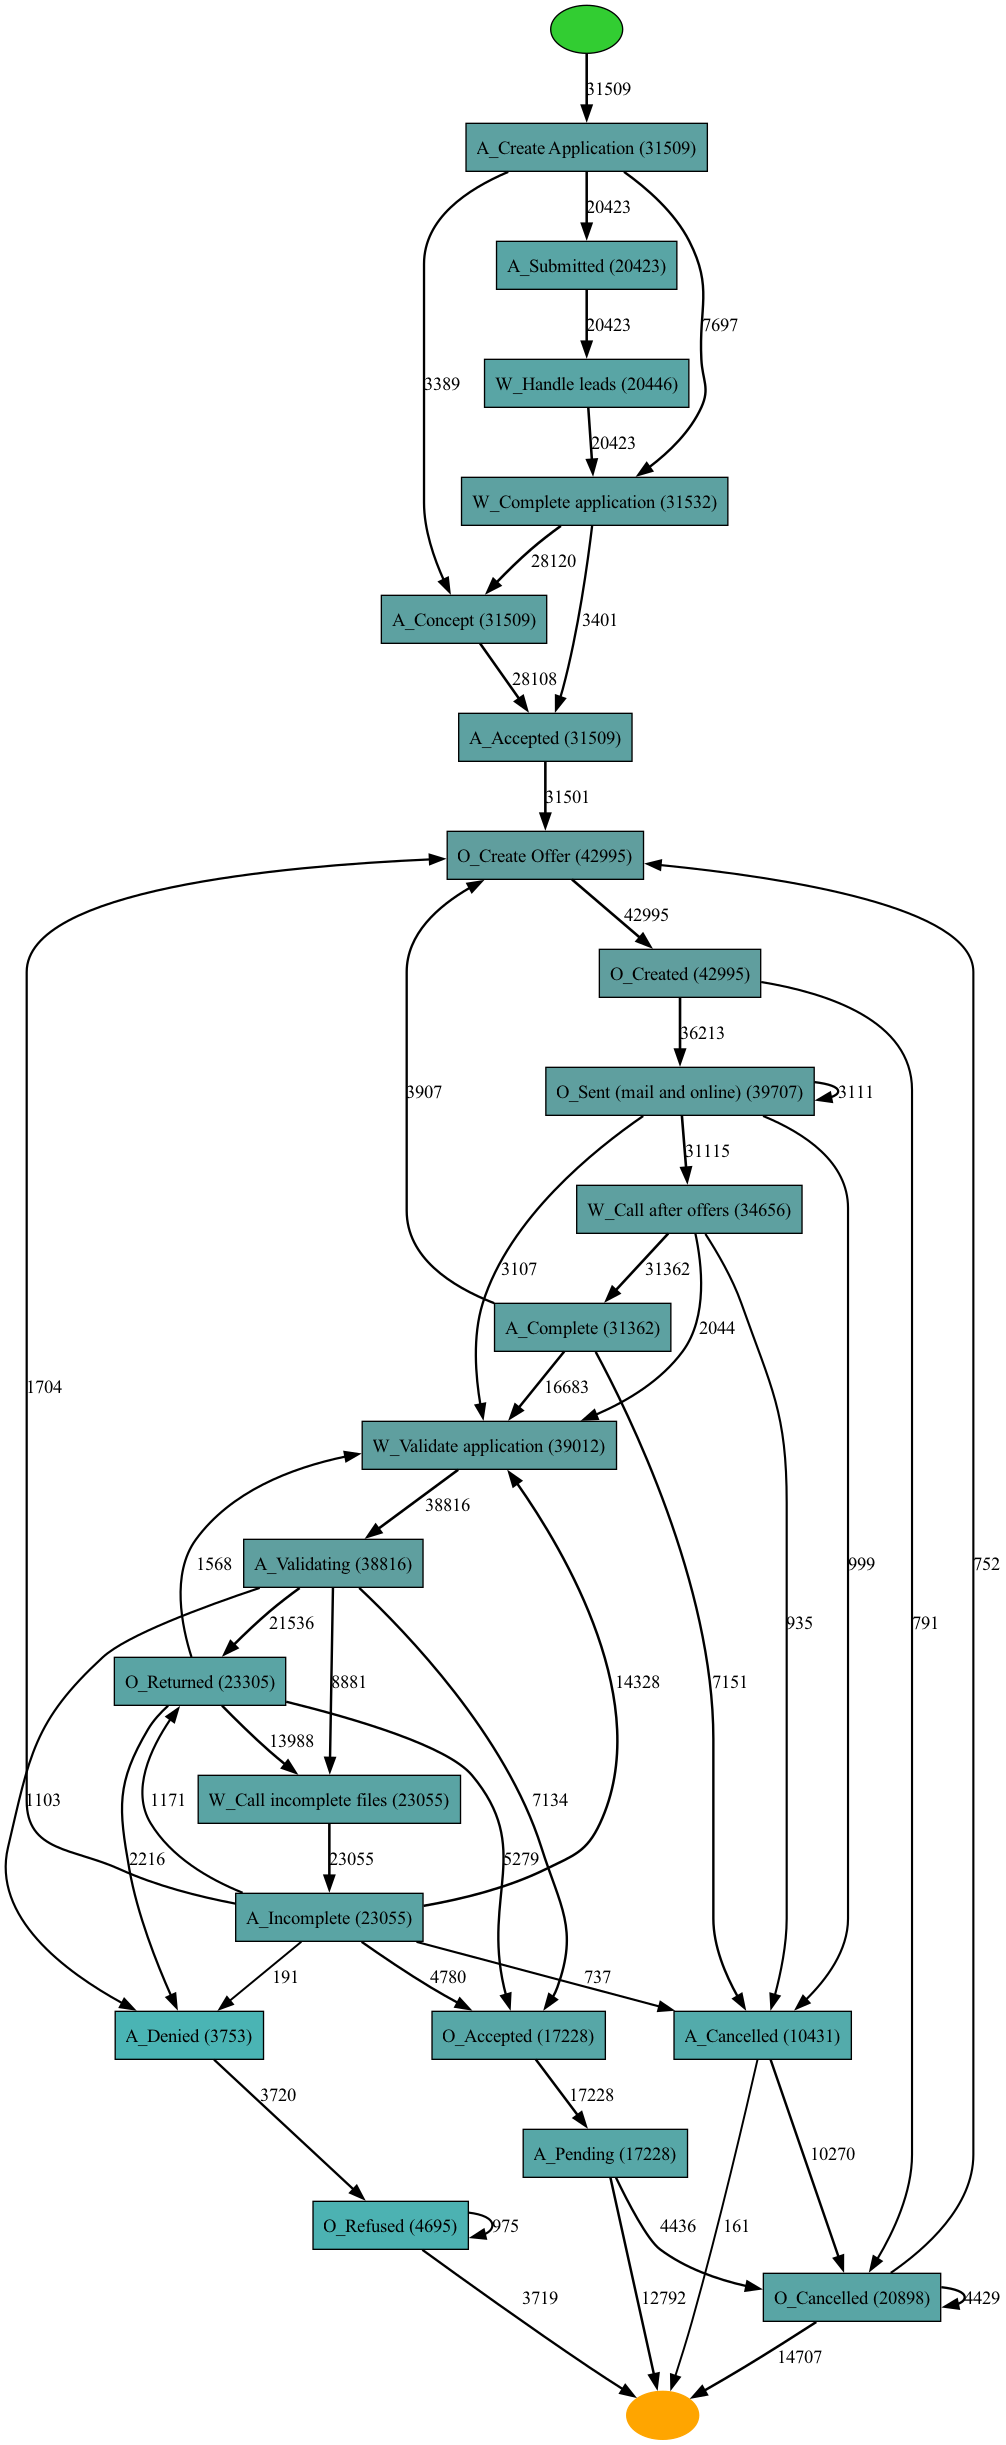

In [73]:
# Default Dependency Threshold of 50%
heu_net_filtered = pm.discover_heuristics_net(df_filtered, min_dfg_occurrences=50)
pm.view_heuristics_net(heu_net_filtered)

In [74]:
bpmn_heu_filtered = pm.convert_to_bpmn(heu_net_filtered)
# pm.view_bpmn(bpmn_heu_filtered)

##### Further analyses using heuristic nets

Analyse application, offer and workflow processes separately

In [75]:
# Split log based on different EventOrigins
app_process = df[df['EventOrigin'] == 'Application']
off_process = df[df['EventOrigin'] == 'Offer']
wf_process = df[df['EventOrigin'] == 'Workflow']
appoff_process = df[df['EventOrigin'].isin(['Application', 'Offer'])]

In [78]:
print(len(app_process), 
len(off_process),
len(wf_process),
len(appoff_process))

239595 193849 768823 433444


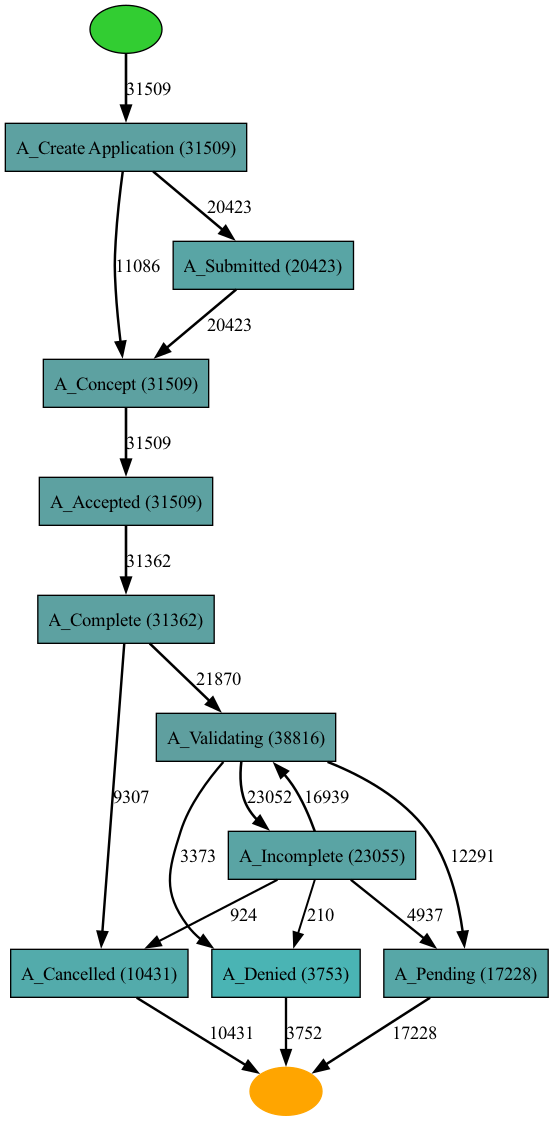

In [79]:
# Filter out irrelevant dfg occurences
app_heu_net = pm.discover_heuristics_net(app_process, min_dfg_occurrences=100)
pm.view_heuristics_net(app_heu_net)

Insights app_heu_net:
- two different ways to submit an application (directly and with extra check (A_Submitted))
- validation after application is accepted
- applications often incomplete --> need to be validated again
- A_Cancelled probably by user since A_Complete --> A_Cancelled both by bank doesn't make sense, A_Denied by bank
- A_Pending as end state

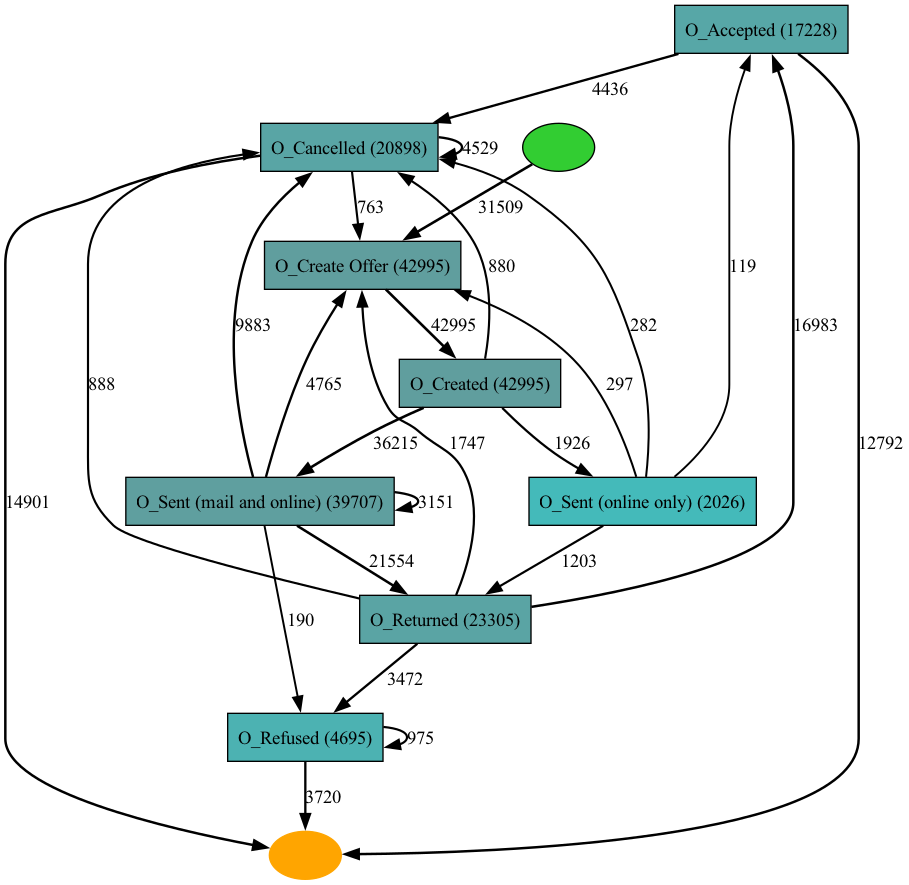

In [80]:
off_heu_net = pm.discover_heuristics_net(off_process, min_dfg_occurrences=100)  # Filter out irrelevant dfg occurences
pm.view_heuristics_net(off_heu_net)

Insights off_heu_net:
- multiple offers can be created
- offers mainly sent via mail & online (multiple times --> loop) but also online only (only once)
- offers are either returned (accepted) by user or cancelled
- if returned bank either accepts or refuses the offer

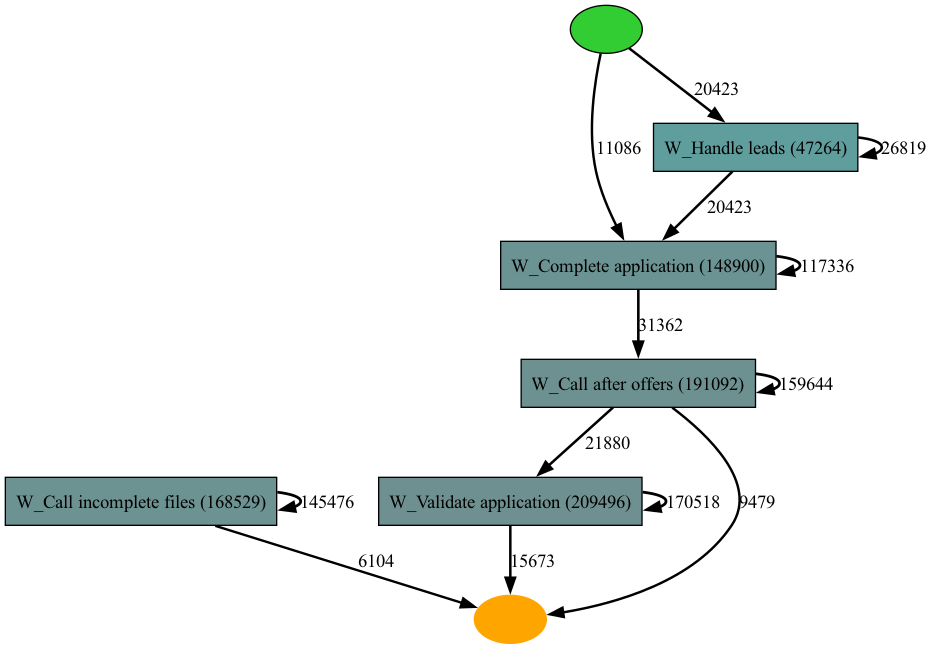

In [81]:
# Filter out W_Shortened completion, W_Personal Loan collection and W_Assess potential fraud
wf_heu_net = pm.discover_heuristics_net(wf_process, min_dfg_occurrences=200, min_act_count=5000)
pm.view_heuristics_net(wf_heu_net)

Insights wf_heu_net:
- Validate application after offer is created not as part of completing application

Combine application and offer processes

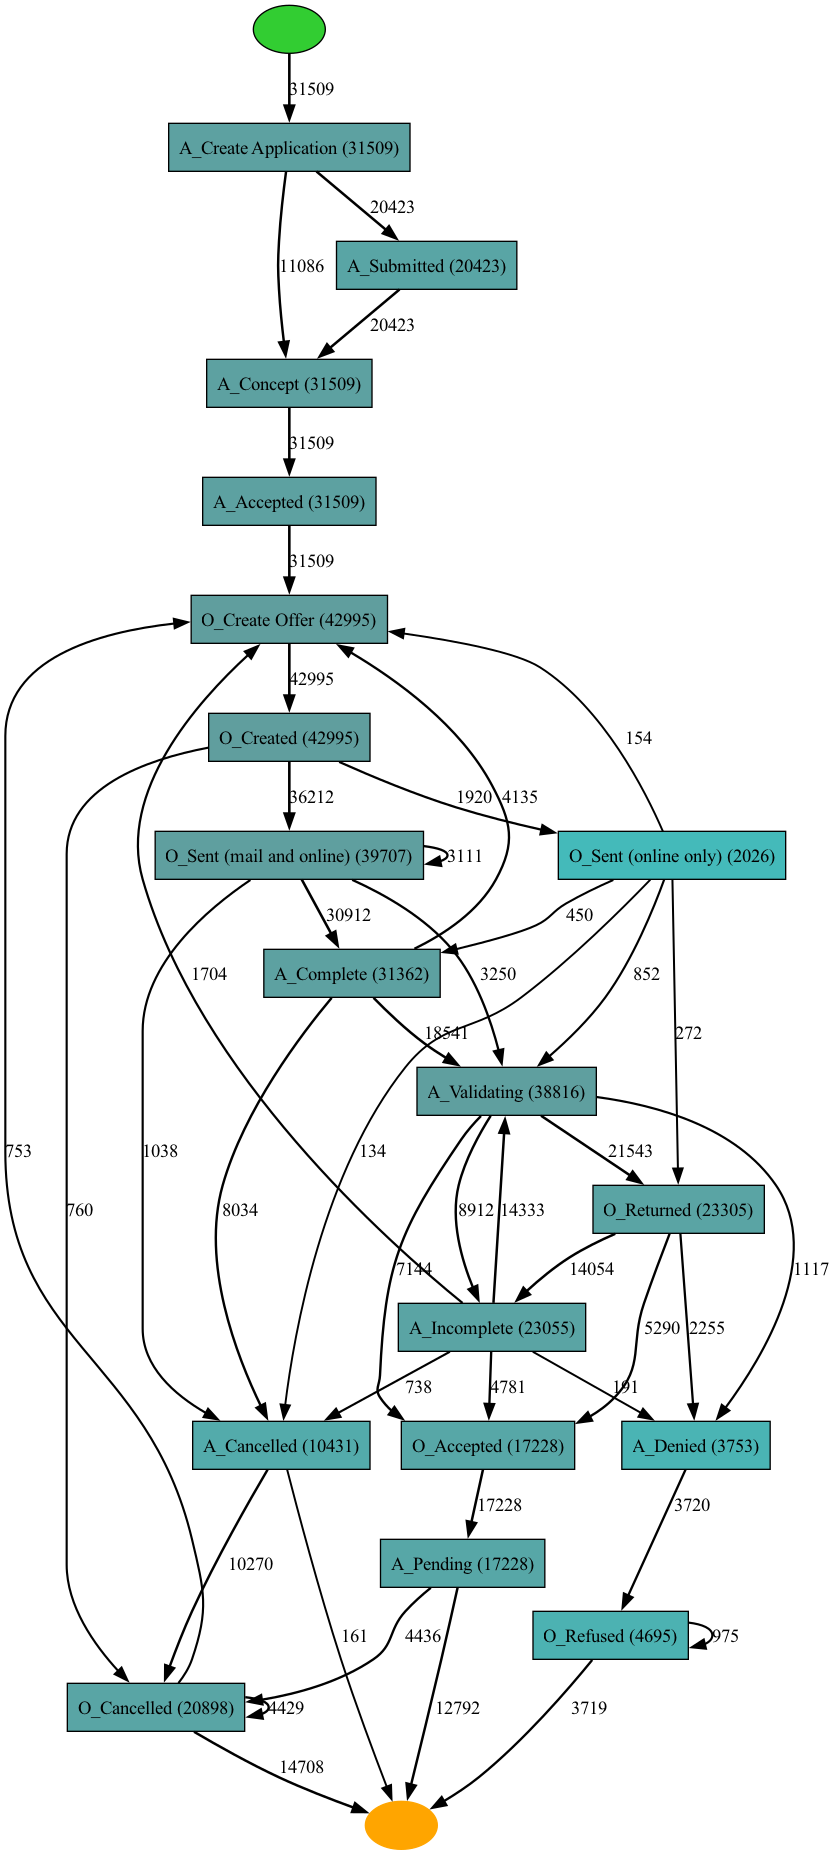

In [82]:
appoff_heu_net = pm.discover_heuristics_net(appoff_process, min_dfg_occurrences=100)
pm.view_heuristics_net(appoff_heu_net)

Insights appoff_heu_net:
- offer(s) created for all applications (after A_Accepted)
- after offers are sent application is always set to complete by the bank and is validated in the next step OR customer cancels application
- online only directly set to A_Validating
- after validation offer is either accepted (signed by user) or send back to the bank (O_Returned) AND bank either denies the application altogether or sets A_Incomplete
- if application is denied by the bank the offer(s) is/are automatically refused as well
- incomplete applications are validated again
- if offer accepted by user status is set to A_Pending (end state)

Include 4 most relevant workflow activities --> see Heuristic Miner/Filtered log

#### Performance DFG

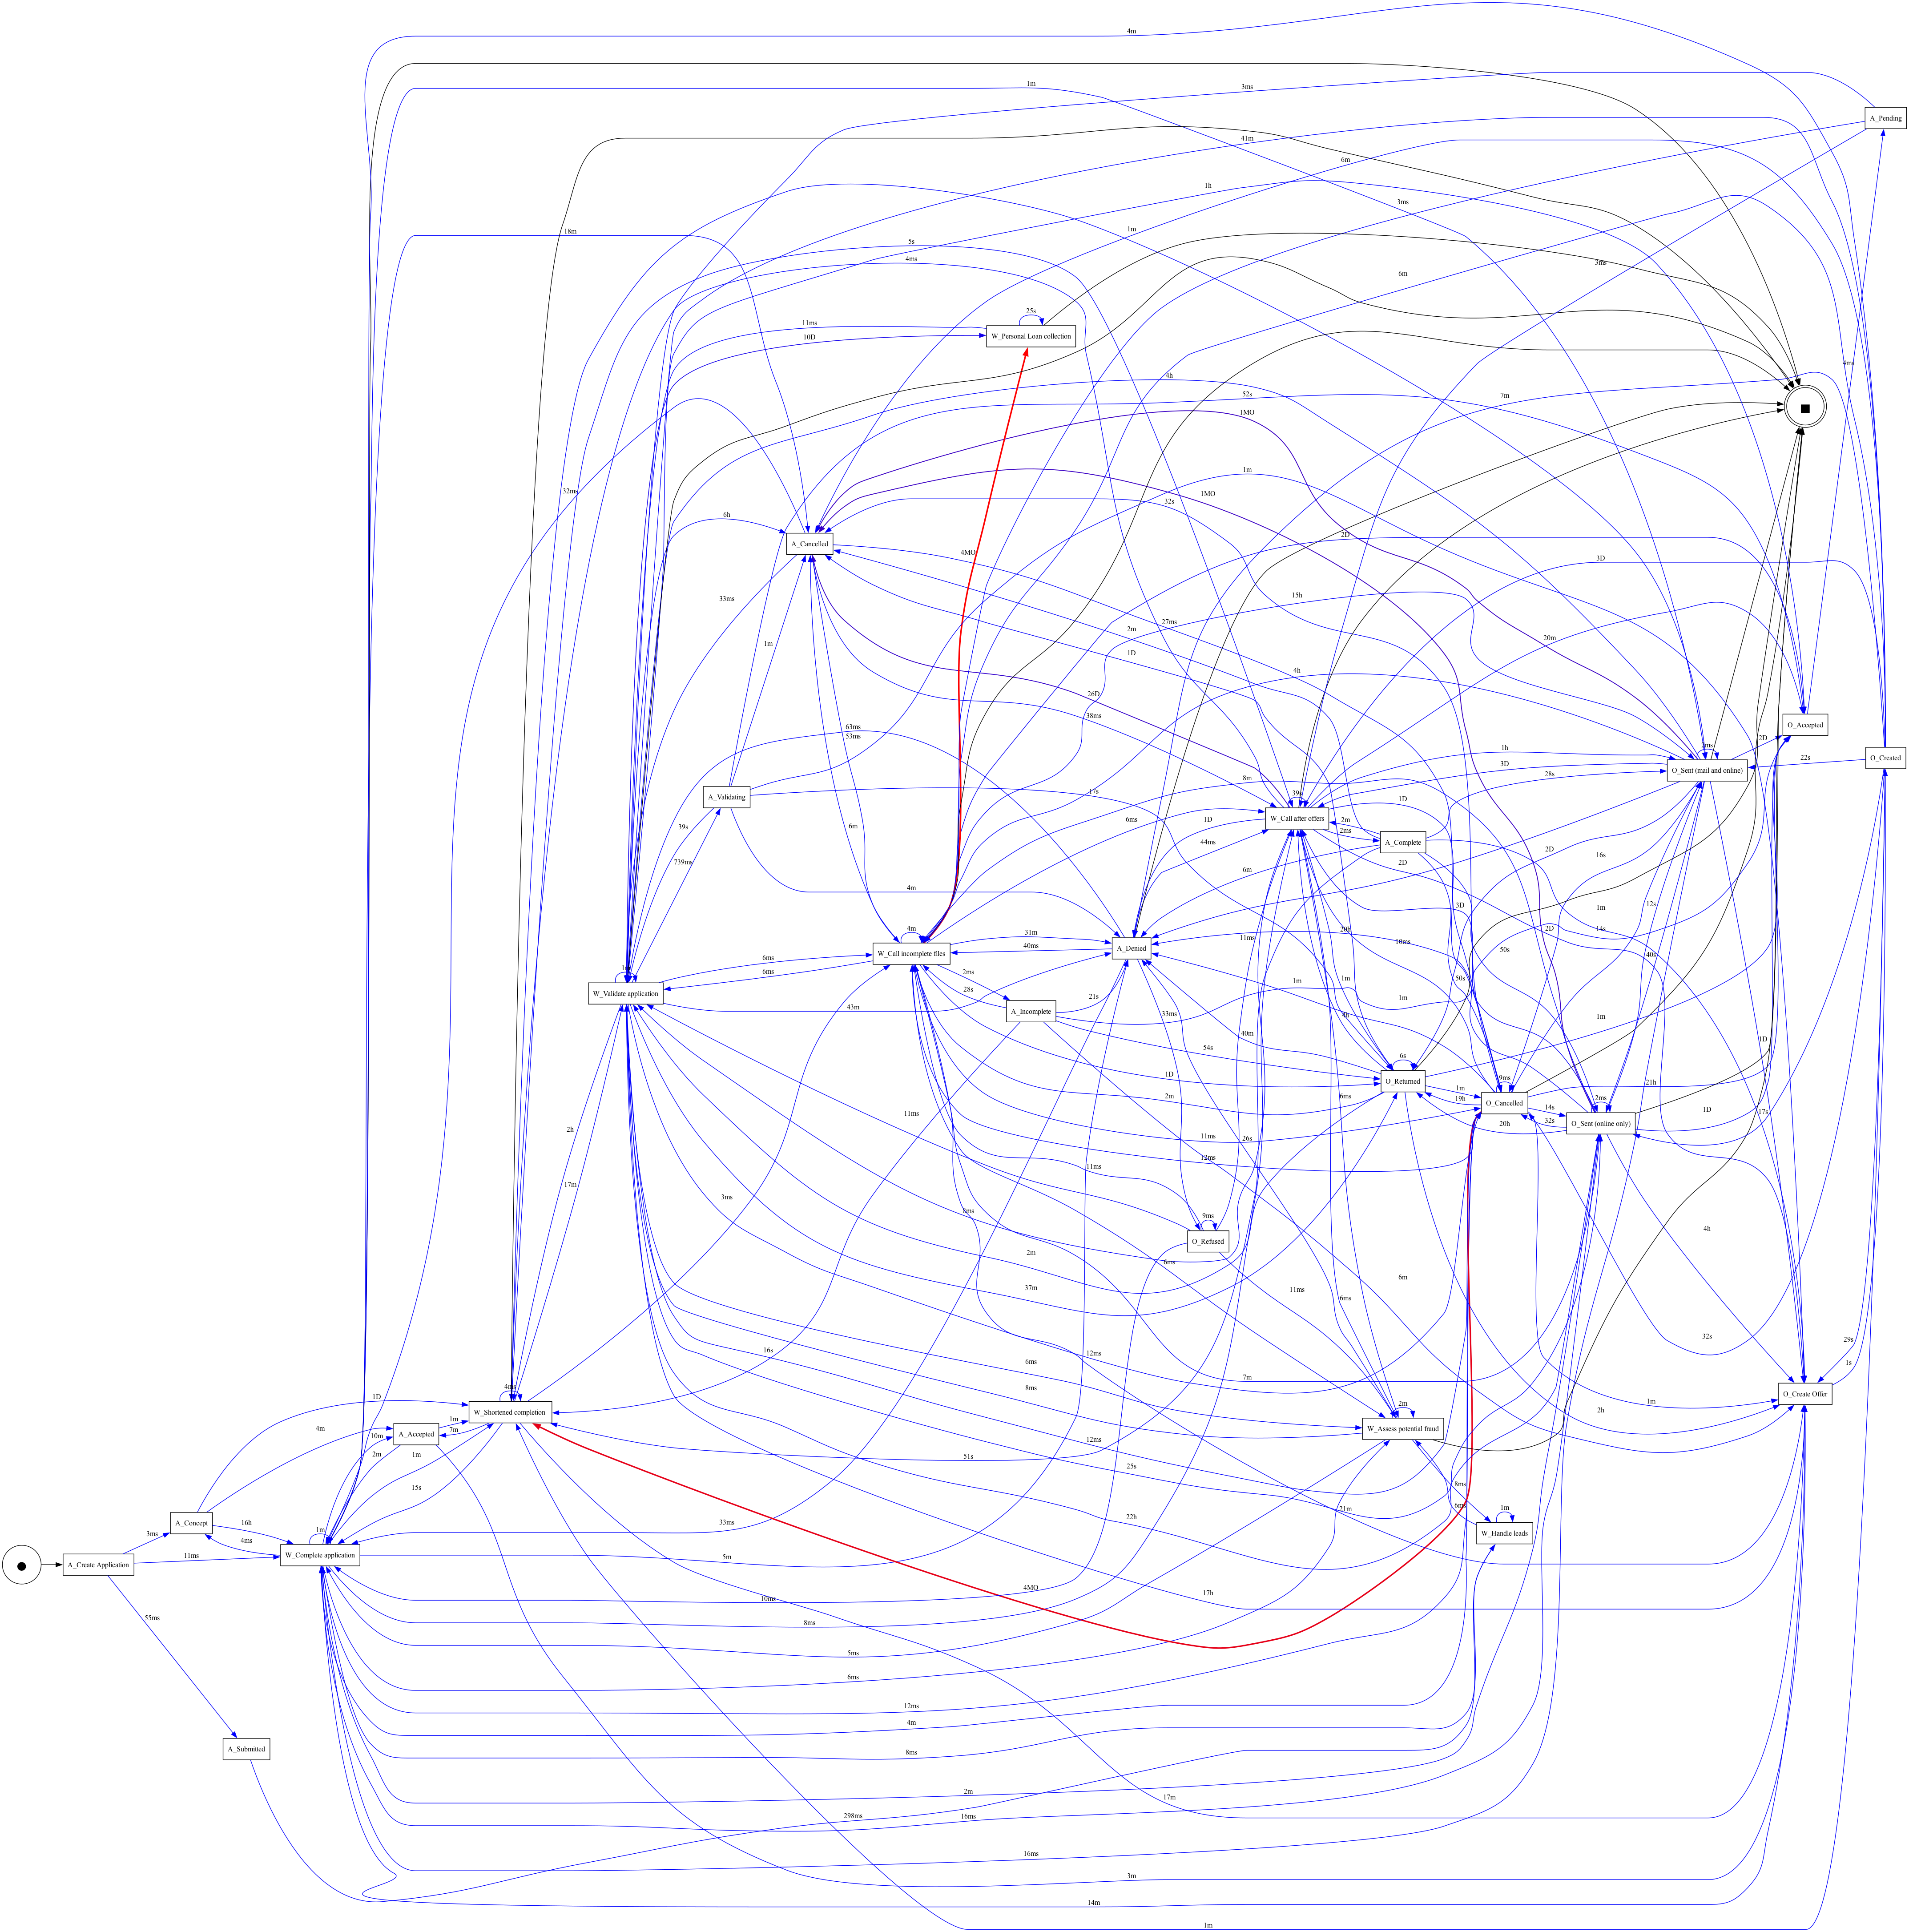

In [83]:
dfg, sa, ea = pm.discover_performance_dfg(df, perf_aggregation_key='median')
pm.view_performance_dfg(dfg, sa, ea)

### Process Modelling

#### Models based on heuristic nets

##### Applications and offers only

In [84]:
own_bpmn_1 = pm.read_bpmn("./process_models/1_applications_and_offers_draft.bpmn")

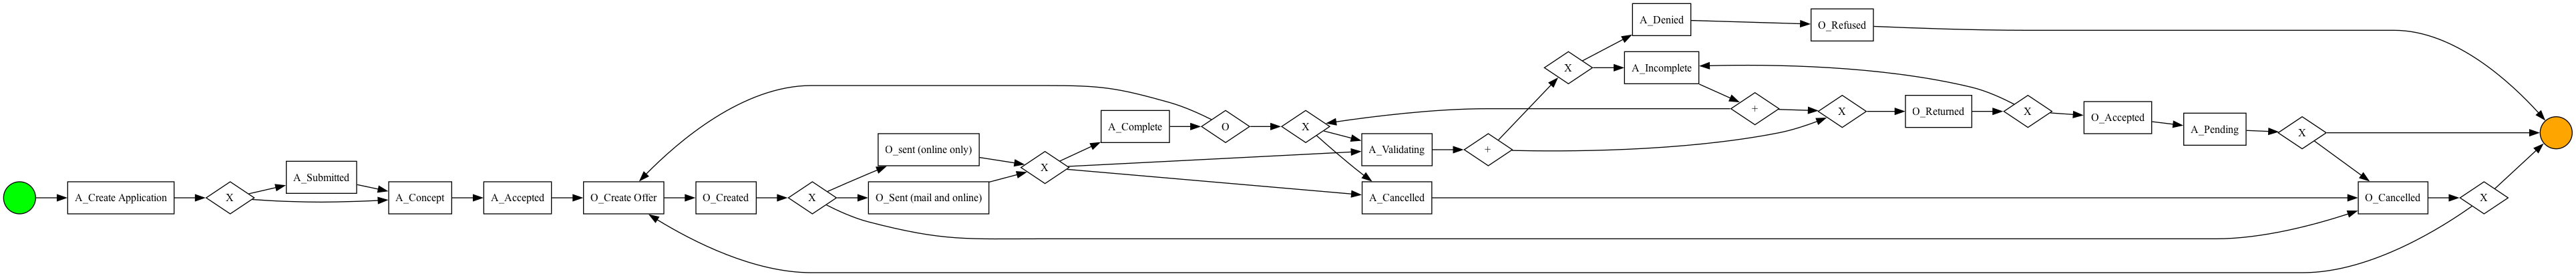

In [85]:
pm.view_bpmn(own_bpmn_1)

In [86]:
own_petri_1, own_im_1, own_fm_1 = pm.convert_to_petri_net(own_bpmn_1)

Fitness

In [87]:
initial_fitness_tokenbased = pm.fitness_token_based_replay(log, own_petri_1, own_im_1, own_fm_1)
initial_fitness_tokenbased

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.9319505721582404,
 'log_fitness': 0.9249920798836062,
 'percentage_of_fitting_traces': 0.0}

In [88]:
initial_fitness_aligments = pm.fitness_alignments(log, own_petri_1, own_im_1, own_fm_1)
initial_fitness_aligments

aligning log, completed variants ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'percFitTraces': 0.0,
 'averageFitness': 0.3281840449809687,
 'percentage_of_fitting_traces': 0.0,
 'average_trace_fitness': 0.3281840449809687,
 'log_fitness': 0.2870244590274481}

Calculate Precision

In [94]:
initial_precision = pm.precision_token_based_replay(log, own_petri_1, own_im_1, own_fm_1)
initial_precision

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

0.25603160825867877

Calculate Generalisation

In [91]:
initial_generalisation = pm.generalization_tbr(log, own_petri_1, own_im_1, own_fm_1)
initial_generalisation

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.9430294673319037

Calculate Simplicity

In [90]:
initial_simplicity = pm.simplicity_petri_net(own_petri_1, own_im_1, own_fm_1)
initial_simplicity

0.7037037037037037

In [124]:
initial_simp_metrics = h.calculate_simplicity_metrics(own_petri_1, own_bpmn_1)
initial_simp_metrics

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,32,69,24,24,18,69.0,2.15625,0.594203


In [125]:
initial_trans_metrics = h.calculate_transitions_table(own_petri_1)
initial_trans_metrics

,Total transitions,Silent transitions,Percentage
0,33,15,45.455%


##### NOT IN REPORT Including relevant workflow events

In [ ]:
own_bpmn_2 = pm.read_bpmn("./process_models/2_app_off_wf_heu.bpmn")
pm.view_bpmn(own_bpmn_2)

In [ ]:
own_petri_2, own_im_2, own_fm_2 = pm.convert_to_petri_net(own_bpmn_2)

Fitness

In [ ]:
pm.fitness_token_based_replay(log, own_petri_2, own_im_2, own_fm_2)

In [ ]:
pm.check_soundness(own_petri_2, own_im_2, own_fm_2)

In [ ]:
pm.fitness_alignments(log, own_petri_2, own_im_2, own_fm_2)

In [ ]:
pm.generalization_tbr(log, own_petri_2, own_im_2, own_fm_2)

In [ ]:
pm.simplicity_petri_net(own_petri_2, own_im_2, own_fm_2)

#### Models created from filtered log

##### Filter 1: only 'Created', 'statechange'

~ 580.000 events -> 
Fitness filtered log: 85-90%
Fitness event log: 50-60%

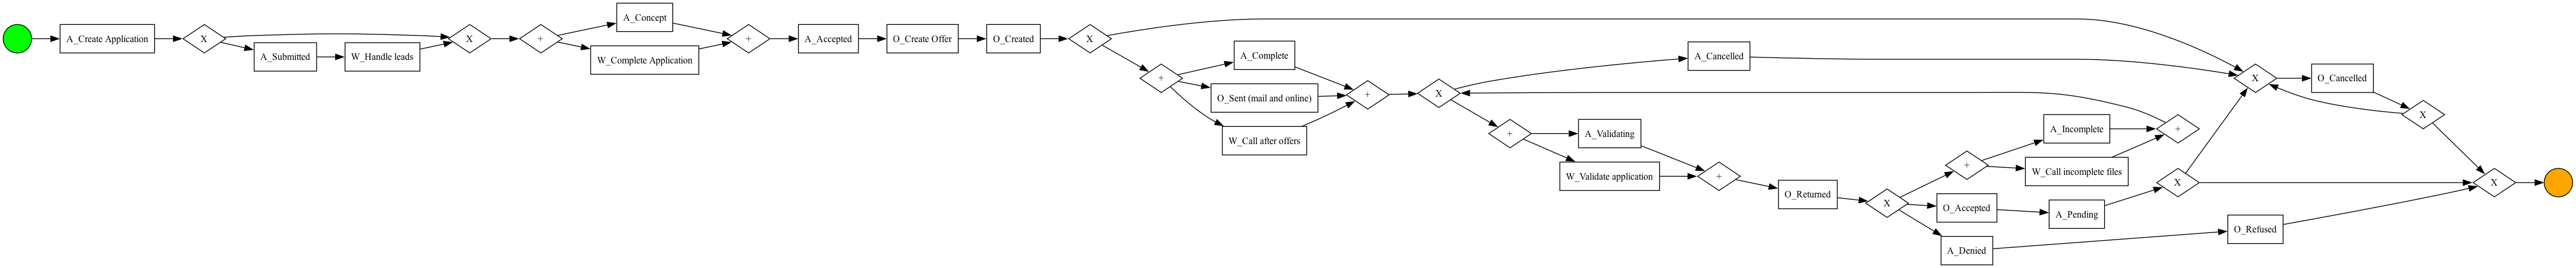

In [95]:
own_bpmn_3 = pm.read_bpmn("./process_models/3_filtered_log_1.bpmn")
pm.view_bpmn(own_bpmn_3)

In [96]:
own_petri_3, own_im_3, own_fm_3 = pm.convert_to_petri_net(own_bpmn_3)

Fitness

In [97]:
pm.fitness_token_based_replay(log, own_petri_3, own_im_3, own_fm_3)

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.6525697066243651,
 'log_fitness': 0.6180304543097109,
 'percentage_of_fitting_traces': 0.0}

Precision

In [98]:
pm.precision_token_based_replay(log, own_petri_3, own_im_3, own_fm_3)

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

0.4725279805821502

Generalisation

In [99]:
pm.generalization_tbr(log, own_petri_3, own_im_3, own_fm_3)

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.9648118768711147

Simplicity

In [100]:
pm.simplicity_petri_net(own_petri_3, own_im_3, own_fm_3)

0.7634408602150538

In [101]:
h.calculate_simplicity_metrics(own_petri_3, own_bpmn_3)

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,41,82,35,35,10,82.0,2.0,0.292683


In [109]:
h.calculate_transitions_table(own_petri_3)

,Total transitions,Silent transitions,Percentage
0,36,14,38.889%


##### Filter 2 - 'Created', 'statechange', 'obtained'

~800.000 Events
70-80% filtered, 67% log

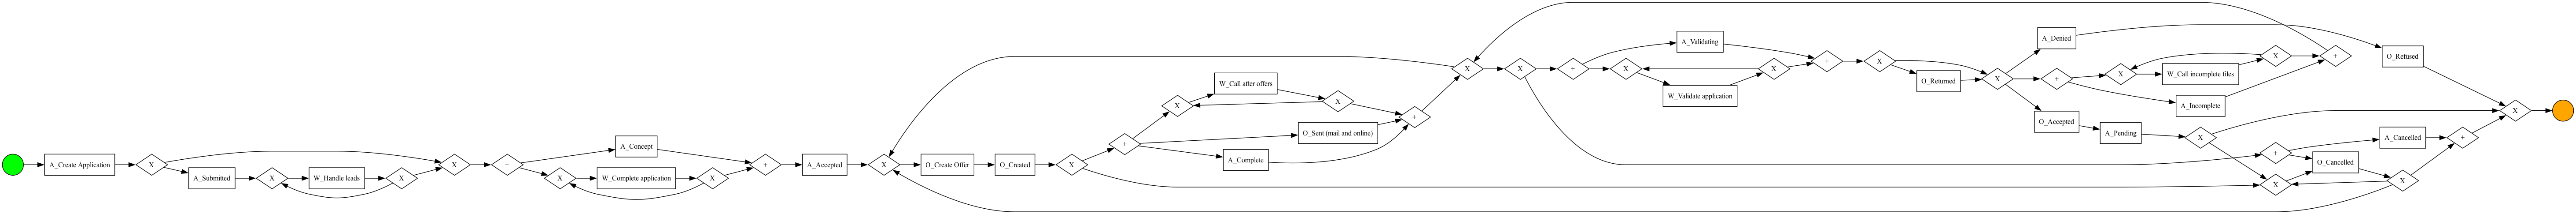

In [111]:
own_bpmn_4 = pm.read_bpmn("./process_models/5_filtered_log_2.bpmn")   # Model derived from filtered miners and csv file using df_filtered_2
pm.view_bpmn(own_bpmn_4)

In [112]:
own_petri_4, own_im_4, own_fm_4 = pm.convert_to_petri_net(own_bpmn_4)

In [113]:
pm.fitness_token_based_replay(log, own_petri_4, own_im_4, own_fm_4)

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.9553273376762152,
 'log_fitness': 0.9587989857478467,
 'percentage_of_fitting_traces': 0.0}

In [114]:
pm.precision_token_based_replay(log, own_petri_4, own_im_4, own_fm_4)

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

0.7422979835624062

In [115]:
pm.generalization_tbr(log, own_petri_4, own_im_4, own_fm_4)

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.9923588358599904

In [116]:
pm.simplicity_petri_net(own_petri_4, own_im_4, own_fm_4)

0.6969696969696969

In [117]:
h.calculate_simplicity_metrics(own_petri_4, own_bpmn_4)

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,56,112,42,42,25,112.0,2.0,0.491071


In [118]:
h.calculate_transitions_table(own_petri_4)

,Total transitions,Silent transitions,Percentage
0,50,28,56.000%


##### Testing different bpmn models

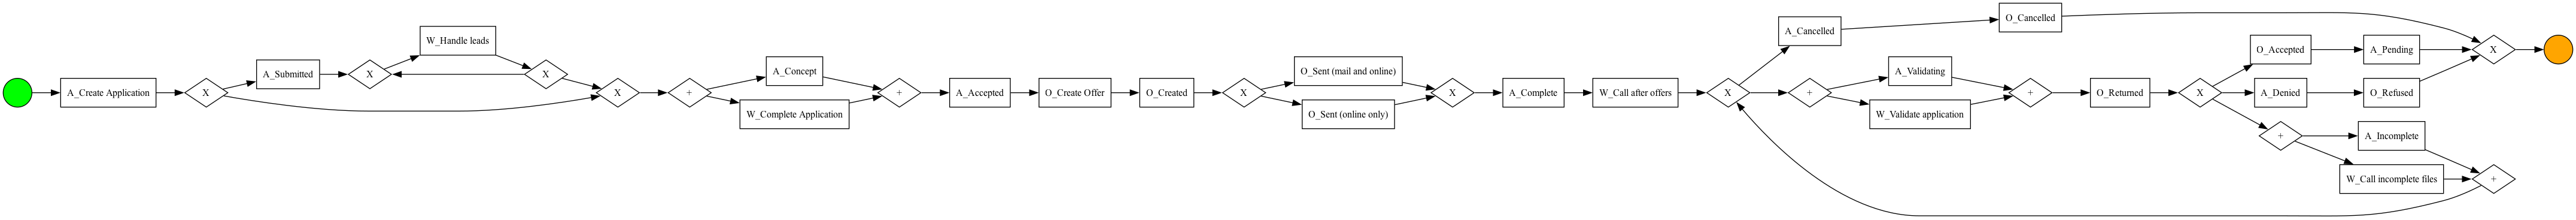

In [119]:
own_bpmn_5 = pm.read_bpmn("./process_models/251116_3_filtered_log_1.bpmn")
pm.view_bpmn(own_bpmn_5)

###### Using df_filtered_2

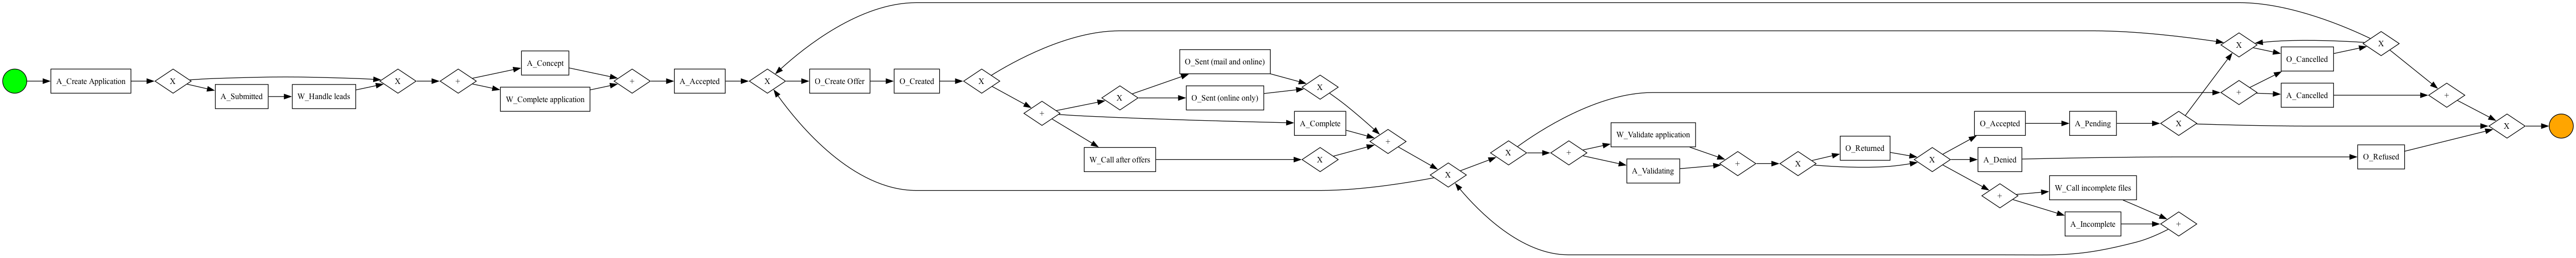

In [120]:
own_bpmn_5 = pm.read_bpmn("./process_models/251117_5_revised.bpmn")
pm.view_bpmn(own_bpmn_5)

In [ ]:
own_petri_5, own_im_5, own_fm_5 = pm.convert_to_petri_net(own_bpmn_5)

In [ ]:
pm.fitness_token_based_replay(log, own_petri_5, own_im_5, own_fm_5)

In [ ]:
pm.precision_token_based_replay(log, own_petri_5, own_im_5, own_fm_5)

In [ ]:
pm.generalization_tbr(log, own_petri_5, own_im_5, own_fm_5)

In [ ]:
pm.simplicity_petri_net(own_petri_5, own_im_5, own_fm_5)

In [ ]:
h.calculate_simplicity_metrics(own_petri_5, own_bpmn_5)

###### df_filtered_3

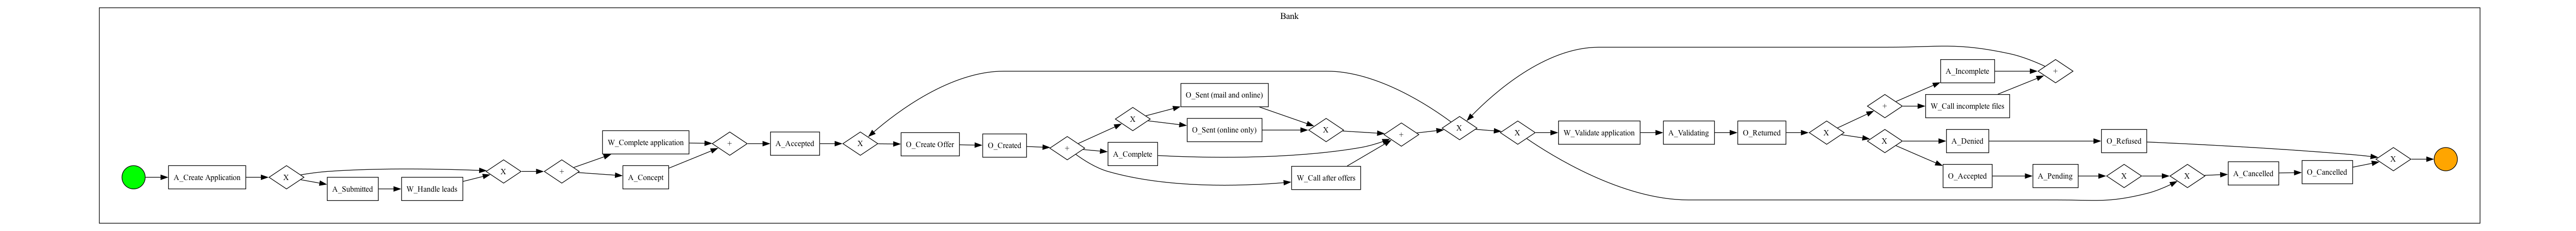

In [121]:
own_bpmn_6 = pm.read_bpmn("./process_models/251116_6_filtered_log_3.bpmn")
pm.view_bpmn(own_bpmn_6)

In [ ]:
own_petri_6, own_im_6, own_fm_6 = pm.convert_to_petri_net(own_bpmn_6)

In [ ]:
pm.fitness_token_based_replay(log, own_petri_6, own_im_6, own_fm_6)

In [ ]:
pm.precision_token_based_replay(log, own_petri_6, own_im_6, own_fm_6)

In [ ]:
pm.generalization_tbr(log, own_petri_6, own_im_6, own_fm_6)

In [ ]:
pm.simplicity_petri_net(own_petri_6, own_im_6, own_fm_6)

###### 3 revised

In [ ]:
test = pm.filter_between(df_filtered, 'O_Created', 'O_Cancelled')
test.head(100)

In [122]:
own_bpmn_7 = pm.read_bpmn("./process_models/7_filtered_log_transitions.bpmn")   # Added cancel multiple offers and create new offer after offer canceled and loop handle leads

In [ ]:
own_petri_7, own_im_7, own_fm_7 = pm.convert_to_petri_net(own_bpmn_7)

In [ ]:
pm.fitness_token_based_replay(df_filtered, own_petri_7, own_im_7, own_fm_7)

In [ ]:
pm.precision_token_based_replay(log, own_petri_7, own_im_7, own_fm_7)

Simplicity

In [ ]:
h.calculate_simplicity_metrics(own_petri_7, own_im_7, own_fm_7)

In [ ]:
h.calculate_transitions_table(own_petri_7)

## Evaluation of Quality Metrics

#### Inductive miner

##### Fitness

In [154]:
ind_fitness_tokenbased = pm.fitness_token_based_replay(log, ind_petri, ind_im, ind_fm)
ind_fitness_tokenbased

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 100.0,
 'average_trace_fitness': 1.0,
 'log_fitness': 1.0,
 'percentage_of_fitting_traces': 100.0}

In [ ]:
ind_fitness_alignment = pm.fitness_alignments(log, ind_petri, ind_im, ind_fm)
ind_fitness_alignment

In [188]:
# ind_fitness_alignment = pm.fitness_alignments(log, ind_petri, ind_im, ind_fm)
ind_fitness_alignment = ind_fitness_tokenbased  # Was run on different processor since it took too long on mine but produced the same result as token-based#

##### Precision

In [149]:
ind_precision = pm.precision_token_based_replay(log, ind_petri, ind_im, ind_fm)
ind_precision

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

0.14004207342751485

##### Generalisation

In [123]:
ind_generalisation = pm.generalization_tbr(log, ind_petri, ind_im, ind_fm)
ind_generalisation

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.9562491641179135

##### Simplicity

In [126]:
ind_simplicity = pm.simplicity_petri_net(ind_petri, ind_im, ind_fm)
ind_simplicity

0.676923076923077

Simplicity metrics from [70] in Conformance Checking

In [128]:
ind_simp_metrics = h.calculate_simplicity_metrics(ind_petri, ind_bpmn)
ind_simp_metrics

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,98,218,72,72,64,218.0,2.22449,0.642202


Silent transitions count

In [129]:
ind_trans_metrics = h.calculate_transitions_table(ind_petri)
ind_trans_metrics

,Total transitions,Silent transitions,Percentage
0,104,78,75.000%


#### Heuristic miner

Evaluated for discovered models using no thresholds and default thresholds

##### Fitness

In [150]:
heu_fitness_tokenbased = pm.fitness_token_based_replay(log, heu_petri, heu_im, heu_fm)
heu_fitness_tokenbased

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.4717612314523713,
 'log_fitness': 0.4492862200707252,
 'percentage_of_fitting_traces': 0.0}

In [151]:
heu_fitness_tokenbased_th = pm.fitness_token_based_replay(log, heu_petri_th, heu_im_th, heu_fm_th)
heu_fitness_tokenbased_th

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.9431922134410836,
 'log_fitness': 0.9507858485934311,
 'percentage_of_fitting_traces': 0.0}

In [153]:
# Using alignments on both heu models took too long to finish
# pm.fitness_alignments(log, heu_petri, heu_im, heu_fm)
# heu_fitness_alignment_th = pm.fitness_alignments(log, heu_petri_th, heu_im_th, heu_fm_th)
heu_fitness_alignment = heu_fitness_alignment_th = float("nan")
print(heu_fitness_alignment, heu_fitness_alignment_th)

nan nan


##### Precision

In [139]:
heu_precision = pm.precision_token_based_replay(log, heu_petri, heu_im, heu_fm)
heu_precision

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

1.0

In [138]:
heu_precision_th = pm.precision_token_based_replay(log, heu_petri_th, heu_im_th, heu_fm_th)
heu_precision_th

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

0.6710730616980617

##### Generalisation

In [137]:
heu_generalisation = pm.generalization_tbr(log, heu_petri, heu_im, heu_fm)
heu_generalisation

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.8915430876333315

In [136]:
heu_generalisation_th = pm.generalization_tbr(log, heu_petri_th, heu_im_th, heu_fm_th)
heu_generalisation_th

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.9170460885062405

##### Simplicity

No threshold

In [130]:
heu_simplicity = pm.simplicity_petri_net(heu_petri, heu_im, heu_fm)
heu_simplicity

0.5497835497835498

In [131]:
heu_simp_metrics = h.calculate_simplicity_metrics(heu_petri, heu_bpmn)
heu_simp_metrics

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,77,179,78,78,15,179.0,2.324675,0.223464


In [132]:
heu_trans_metrics = h.calculate_transitions_table(heu_petri)
heu_trans_metrics

,Total transitions,Silent transitions,Percentage
0,49,23,46.939%


Default threshold

In [133]:
heu_simplicity_th = pm.simplicity_petri_net(heu_petri_th, heu_im_th, heu_fm_th)
heu_simplicity_th

0.5186721991701245

In [134]:
heu_simp_metrics_th = h.calculate_simplicity_metrics(heu_petri_th, heu_bpmn_th)
heu_simp_metrics_th

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,83,183,43,43,36,183.0,2.204819,0.737705


In [135]:
heu_trans_metrics_th = h.calculate_transitions_table(heu_petri_th)
heu_trans_metrics_th

,Total transitions,Silent transitions,Percentage
0,82,56,68.293%


#### Final bpmn model

In [157]:
my_bpmn = pm.read_bpmn("./final_model.bpmn")

In [158]:
my_net, my_im, my_fm = pm.convert_to_petri_net(my_bpmn)

##### Fitness

In [159]:
my_fitness_tokenbased = pm.fitness_token_based_replay(log, my_net, my_im, my_fm)
my_fitness_tokenbased

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.9555911514203975,
 'log_fitness': 0.959072051489308,
 'percentage_of_fitting_traces': 0.0}

In [148]:
my_fitness_alignments = pm.fitness_alignments(log, my_net, my_im, my_fm)
my_fitness_alignments

aligning log, completed variants ::   0%|          | 0/15930 [00:00<?, ?it/s]

{'percFitTraces': 0.0,
 'averageFitness': 0.9152234832848775,
 'percentage_of_fitting_traces': 0.0,
 'average_trace_fitness': 0.9152234832848775,
 'log_fitness': 0.9149533418395372}

##### Precision

In [146]:
my_precision = pm.precision_token_based_replay(log, my_net, my_im, my_fm)
my_precision

replaying log with TBR, completed traces ::   0%|          | 0/263907 [00:00<?, ?it/s]

0.7422979835624062

##### Generalisation

In [145]:
my_generalisation = pm.generalization_tbr(log, my_net, my_im, my_fm)
my_generalisation

replaying log with TBR, completed traces ::   0%|          | 0/15930 [00:00<?, ?it/s]

0.9923547418034212

##### Simplicity

In [142]:
my_simplicity = pm.simplicity_petri_net(my_net, my_im, my_fm)
my_simplicity

0.7014925373134328

In [162]:
my_simp_metrics = h.calculate_simplicity_metrics(my_net, my_bpmn)
my_simp_metrics

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality
0,64,114,43,43,26,114.0,1.78125,0.491228


In [163]:
my_trans_metrics = h.calculate_transitions_table(my_net)
my_trans_metrics

,Total transitions,Silent transitions,Percentage
0,51,29,56.863%


### Comparison

Overview over quality metrics

In [164]:
qm_results = pd.DataFrame({
    'Fitness (token-based)': [ind_fitness_tokenbased, heu_fitness_tokenbased, heu_fitness_tokenbased_th, initial_fitness_tokenbased, my_fitness_tokenbased],
    'Fitness (alignment-based)': [ind_fitness_alignment, heu_fitness_alignment, heu_fitness_alignment_th, initial_fitness_aligments, my_fitness_alignments],
    'Precision': [ind_precision, heu_precision, heu_precision_th, initial_precision, my_precision],
    'Generalisation': [ind_generalisation, heu_generalisation, heu_generalisation_th, initial_generalisation, my_generalisation],
    'Simplicity': [ind_simplicity, heu_simplicity, heu_simplicity_th, initial_simplicity, my_simplicity]
})
qm_results.index = ['Inductive', 'Heuristic', 'Heuristic with threshold', 'Initial model', 'Final bpmn model']
qm_results

,Fitness (token-based),Fitness (alignment-based),Precision,Generalisation,Simplicity
Inductive,"{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}","{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}",0.140042,0.956249,0.676923
Heuristic,"{'perc_fit_traces': 0.0, 'average_trace_fitness': 0.4717612314523713, 'log_fitness': 0.4492862200707252, 'percentage_of_fitting_traces': 0.0}",NaN,1.000000,0.891543,0.549784
Heuristic with threshold,"{'perc_fit_traces': 0.0, 'average_trace_fitness': 0.9431922134410836, 'log_fitness': 0.9507858485934311, 'percentage_of_fitting_traces': 0.0}",NaN,0.671073,0.917046,0.518672
Initial model,"{'perc_fit_traces': 0.0, 'average_trace_fitness': 0.9319505721582404, 'log_fitness': 0.9249920798836062, 'percentage_of_fitting_traces': 0.0}","{'percFitTraces': 0.0, 'averageFitness': 0.3281840449809687, 'percentage_of_fitting_traces': 0.0, 'average_trace_fitness': 0.3281840449809687, 'log_fitness': 0.2870244590274481}",0.256032,0.943029,0.703704
Final bpmn model,"{'perc_fit_traces': 0.0, 'average_trace_fitness': 0.9555911514203975, 'log_fitness': 0.959072051489308, 'percentage_of_fitting_traces': 0.0}","{'percFitTraces': 0.0, 'averageFitness': 0.9152234832848775, 'percentage_of_fitting_traces': 0.0, 'average_trace_fitness': 0.9152234832848775, 'log_fitness': 0.9149533418395372}",0.742298,0.992355,0.701493


Overview over all simplicity metrics

In [182]:
# Combine simple metrics and transision dataframes
ind_simplicity_results = h.combine_simplicity_dataframes(ind_simp_metrics, ind_trans_metrics)
heu_simplicity_results = h.combine_simplicity_dataframes(heu_simp_metrics, heu_trans_metrics)
heu_simplicity_results_th = h.combine_simplicity_dataframes(heu_simp_metrics_th, heu_trans_metrics_th)
initial_simplicity_results = h.combine_simplicity_dataframes(initial_simp_metrics, initial_trans_metrics)
my_simplicity_results = h.combine_simplicity_dataframes(my_simp_metrics, my_trans_metrics)

In [186]:
# Show resultsin new dataframe using 
simplicity_results = pd.concat([
    ind_simplicity_results,
    heu_simplicity_results,
    heu_simplicity_results_th,
    initial_simplicity_results,
    my_simplicity_results
], axis=0)

simplicity_results.index = ['Inductive', 'Heuristic', 'Heuristic with threshold', 'Initial bpmn model', 'Final bpmn model']
simplicity_results

,Nodes,Arcs,In arcs,Out arcs,Gateways,Density,Coefficient of Connectivity (CNC),Sequentiality,Total transitions,Silent transitions,Percentage
Inductive,98.0,218.0,72.0,72.0,64.0,218.0,2.224490,0.642202,104.0,78.0,75.000%
Heuristic,77.0,179.0,78.0,78.0,15.0,179.0,2.324675,0.223464,49.0,23.0,46.939%
Heuristic with threshold,83.0,183.0,43.0,43.0,36.0,183.0,2.204819,0.737705,82.0,56.0,68.293%
Initial bpmn model,32.0,69.0,24.0,24.0,18.0,69.0,2.156250,0.594203,33.0,15.0,45.455%
Final bpmn model,64.0,114.0,43.0,43.0,26.0,114.0,1.781250,0.491228,51.0,29.0,56.863%


## Advanced Analysis

In [ ]:
# import matplotlib.pyplot as plt

### Logistic Regression for A_Cancelled & A_Pending

In [ ]:
# from sklearn.linear_model import LogisticRegression
import pandas as pd
import pm4py as pm
from sklearn.preprocessing import LabelEncoder #, StandardScaler
# from sklearn.model_selection import train_test_split
#from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

#### Prepare data

Find all cases containing A_Cancelled or A_Pending

In [294]:
df_cancelled = pm.filter_activities_rework(df, 'A_Cancelled', min_occurrences=1)
df_pending = pm.filter_activities_rework(df, 'A_Pending', min_occurrences=1)
print(len(df_cancelled), len(df_pending))

273749 779168


In [285]:
df_logreg = pd.concat([df_cancelled, df_pending])
len(df_logreg)

1052917

Calculate different business metrics grouped by application ID

In [278]:
# Used for X
df_logreg['w_handle_leads'] = (df_logreg['concept:name'] == 'W_Handle leads').astype(int)
df_logreg['w_complete_app'] = (df_logreg['concept:name'] == 'W_Complete application').astype(int)
df_logreg['w_call_after_off'] = (df_logreg['concept:name'] == 'W_Call after offers').astype(int)
df_logreg['w_call_incmplt_files'] = (df_logreg['concept:name'] == 'W_Call incomplete files').astype(int)

# Used for y
df_logreg['a_cancelled'] = (df_logreg['concept:name'] == 'A_Cancelled').astype(int)


df_cases = df_logreg.groupby('case:concept:name').agg(
    a_cancelled = ('a_cancelled', 'sum'),

    # Loan related or "business metrics"
    loan_goal=('case:LoanGoal', 'last'),
    app_type=('case:ApplicationType', 'last'),
    req_amount=('case:RequestedAmount', 'last'),
    off_amount=('OfferedAmount', 'last'),
    monthly_cost=('MonthlyCost', 'last'),
    num_of_terms=('NumberOfTerms', 'last'),
    first_withdrawal=('FirstWithdrawalAmount', 'last'),

    # Workflows
    w_handle_leads=('w_handle_leads', 'sum'),
    w_complete_app=('w_complete_app', 'sum'),
    w_call_after_off=('w_call_after_off', 'sum'),
    w_call_incmplt_files=('w_call_incmplt_files', 'sum'),

    # Used to calculate duration of one case
    start_time = ('time:timestamp', 'min'),
    end_time = ('time:timestamp', 'max')
)

df_cases['case_duration'] = (df_cases['end_time'] - df_cases['start_time']).dt.days
df_cases

,a_cancelled,loan_goal,app_type,req_amount,off_amount,monthly_cost,num_of_terms,first_withdrawal,w_handle_leads,w_complete_app,w_call_after_off,w_call_incmplt_files,start_time,end_time,case_duration
case:concept:name,,,,,,,,,,,,,,,
Application_1000086665,1,"Other, see explanation",New credit,5000.0,5000.0,241.28,22.0,5000.0,2,4,6,0,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,32
Application_1000158214,0,Home improvement,New credit,12500.0,12500.0,250.00,57.0,0.0,2,3,4,0,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,8
Application_1000311556,1,Car,New credit,45000.0,45000.0,500.00,111.0,0.0,0,3,6,0,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,30
Application_1000339879,0,Existing loan takeover,New credit,37500.0,37500.0,375.00,126.0,0.0,2,3,6,8,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,12
Application_100034150,0,Existing loan takeover,New credit,5000.0,5000.0,56.30,120.0,577.0,3,5,6,8,2016-02-26 08:17:08.702000+00:00,2016-03-08 11:35:09.066000+00:00,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Application_999507989,0,Not speficied,New credit,24000.0,24000.0,250.00,120.0,1000.0,2,4,6,8,2016-03-17 06:53:36.792000+00:00,2016-03-23 14:08:12.530000+00:00,6
Application_999544538,0,Car,New credit,50000.0,50000.0,509.11,120.0,0.0,2,3,8,30,2016-05-07 11:46:42.914000+00:00,2016-07-26 06:35:18.221000+00:00,79
Application_999632431,1,Existing loan takeover,New credit,12000.0,12000.0,149.86,98.0,0.0,2,5,6,0,2016-12-15 12:24:56.147000+00:00,2017-01-16 07:00:30.457000+00:00,31


Calculate X and y for regression model

In [279]:
X = df_cases.drop(['start_time', 'end_time', 'a_cancelled'], axis=1)
X.reset_index(drop=True)

,loan_goal,app_type,req_amount,off_amount,monthly_cost,num_of_terms,first_withdrawal,w_handle_leads,w_complete_app,w_call_after_off,w_call_incmplt_files,case_duration
0,"Other, see explanation",New credit,5000.0,5000.0,241.28,22.0,5000.0,2,4,6,0,32
1,Home improvement,New credit,12500.0,12500.0,250.00,57.0,0.0,2,3,4,0,8
2,Car,New credit,45000.0,45000.0,500.00,111.0,0.0,0,3,6,0,30
3,Existing loan takeover,New credit,37500.0,37500.0,375.00,126.0,0.0,2,3,6,8,12
4,Existing loan takeover,New credit,5000.0,5000.0,56.30,120.0,577.0,3,5,6,8,11
...,...,...,...,...,...,...,...,...,...,...,...,...
27654,Not speficied,New credit,24000.0,24000.0,250.00,120.0,1000.0,2,4,6,8,6
27655,Car,New credit,50000.0,50000.0,509.11,120.0,0.0,2,3,8,30,79
27656,Existing loan takeover,New credit,12000.0,12000.0,149.86,98.0,0.0,2,5,6,0,31
27657,Home improvement,Limit raise,10000.0,15000.0,250.00,69.0,0.0,0,5,6,0,13


In [280]:
y = df_cases[['a_cancelled']]
y.reset_index(drop=True)

,a_cancelled
0,1
1,0
2,1
3,0
4,0
...,...
27654,0
27655,0
27656,1
27657,0


Encode categorical columns

In [286]:
le = LabelEncoder()
X['loan_goal'] = le.fit_transform(X['loan_goal'])
X['app_type'] = le.fit_transform(X['app_type'])
X

,loan_goal,app_type,req_amount,off_amount,monthly_cost,num_of_terms,first_withdrawal,w_handle_leads,w_complete_app,w_call_after_off,w_call_incmplt_files,case_duration
case:concept:name,,,,,,,,,,,,
Application_1000086665,10,1,5000.0,5000.0,241.28,22.0,5000.0,2,4,6,0,32
Application_1000158214,7,1,12500.0,12500.0,250.00,57.0,0.0,2,3,4,0,8
Application_1000311556,2,1,45000.0,45000.0,500.00,111.0,0.0,0,3,6,0,30
Application_1000339879,5,1,37500.0,37500.0,375.00,126.0,0.0,2,3,6,8,12
Application_100034150,5,1,5000.0,5000.0,56.30,120.0,577.0,3,5,6,8,11
...,...,...,...,...,...,...,...,...,...,...,...,...
Application_999507989,9,1,24000.0,24000.0,250.00,120.0,1000.0,2,4,6,8,6
Application_999544538,2,1,50000.0,50000.0,509.11,120.0,0.0,2,3,8,30,79
Application_999632431,5,1,12000.0,12000.0,149.86,98.0,0.0,2,5,6,0,31


Validate encoded data

In [197]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27659 entries, Application_1000086665 to Application_999993812
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_goal             27659 non-null  int64  
 1   app_type              27659 non-null  int64  
 2   req_amount            27659 non-null  float64
 3   off_amount            27659 non-null  float64
 4   monthly_cost          27659 non-null  float64
 5   num_of_terms          27659 non-null  float64
 6   first_withdrawal      27659 non-null  float64
 7   w_handle_leads        27659 non-null  int64  
 8   w_complete_app        27659 non-null  int64  
 9   w_call_after_off      27659 non-null  int64  
 10  w_call_incmplt_files  27659 non-null  int64  
 11  case_duration         27659 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 3.8+ MB


In [198]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27659 entries, Application_1000086665 to Application_999993812
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   a_cancelled  27659 non-null  int64
dtypes: int64(1)
memory usage: 1.4+ MB


#### Train model

##### Train regression model on business and workflow

In [295]:
# Train model and retrieve test data
y_test, y_test_pred, y_test_proba = h.train_model(X, y)

/Users/matildabriegel/opt/anaconda3/envs/bppso/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Retrieve relevant data

In [219]:
cm_entire = confusion_matrix(y_test, y_test_pred)
cm_entire

array([[2994,  452],
       [ 383, 1703]])

In [221]:
cr_entire = classification_report(y_test, y_test_pred, target_names=['A_Pending', 'A_Cancelled'])
print(cr_entire)

              precision    recall  f1-score   support

   A_Pending       0.89      0.87      0.88      3446
 A_Cancelled       0.79      0.82      0.80      2086

    accuracy                           0.85      5532
   macro avg       0.84      0.84      0.84      5532
weighted avg       0.85      0.85      0.85      5532



##### Train only business related columns

In [222]:
X_b = X.drop(columns=['w_handle_leads',	'w_complete_app',	'w_call_after_off',	'w_call_incmplt_files',	'case_duration'])
X_b

,loan_goal,app_type,req_amount,off_amount,monthly_cost,num_of_terms,first_withdrawal
case:concept:name,,,,,,,
Application_1000086665,10,1,5000.0,5000.0,241.28,22.0,5000.0
Application_1000158214,7,1,12500.0,12500.0,250.00,57.0,0.0
Application_1000311556,2,1,45000.0,45000.0,500.00,111.0,0.0
Application_1000339879,5,1,37500.0,37500.0,375.00,126.0,0.0
Application_100034150,5,1,5000.0,5000.0,56.30,120.0,577.0
...,...,...,...,...,...,...,...
Application_999507989,9,1,24000.0,24000.0,250.00,120.0,1000.0
Application_999544538,2,1,50000.0,50000.0,509.11,120.0,0.0
Application_999632431,5,1,12000.0,12000.0,149.86,98.0,0.0


In [224]:
y_test_b, y_test_pred_b, y_test_proba_b = h.train_model(X_b, y)

/Users/matildabriegel/opt/anaconda3/envs/bppso/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [225]:
cm_business = confusion_matrix(y_test_b, y_test_pred_b)
cm_business

array([[1719, 1727],
       [ 774, 1312]])

In [226]:
cr_business = classification_report(y_test_b, y_test_pred_b, target_names=['A_Pending', 'A_Cancelled'])
print(cr_business)

              precision    recall  f1-score   support

   A_Pending       0.69      0.50      0.58      3446
 A_Cancelled       0.43      0.63      0.51      2086

    accuracy                           0.55      5532
   macro avg       0.56      0.56      0.55      5532
weighted avg       0.59      0.55      0.55      5532



Calculate metrics

In [ ]:
TN_b = cm_b[0,0]
FP_b = cm_b[0,1]
FN_b = cm_b[1,0]
TP_b = cm_b[1,1]

In [ ]:
sensitivity_b = TP_b / (TP_b + FN_b)
sensitivity_b

##### Train workflow related columns

In [228]:
X_w = X.drop(columns=['loan_goal',	'app_type',	'req_amount', 'off_amount',	'monthly_cost',	'num_of_terms',	'first_withdrawal'])
X_w

,w_handle_leads,w_complete_app,w_call_after_off,w_call_incmplt_files,case_duration
case:concept:name,,,,,
Application_1000086665,2,4,6,0,32
Application_1000158214,2,3,4,0,8
Application_1000311556,0,3,6,0,30
Application_1000339879,2,3,6,8,12
Application_100034150,3,5,6,8,11
...,...,...,...,...,...
Application_999507989,2,4,6,8,6
Application_999544538,2,3,8,30,79
Application_999632431,2,5,6,0,31


In [229]:
y_test_w, y_test_pred_w, y_test_proba_w = h.train_model(X_w, y)

/Users/matildabriegel/opt/anaconda3/envs/bppso/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [230]:
cm_workflow = confusion_matrix(y_test_w, y_test_pred_w)
cm_workflow

array([[2998,  448],
       [ 392, 1694]])

In [231]:
cr_workflow = classification_report(y_test_w, y_test_pred_w, target_names=['A_Pending', 'A_Cancelled'])
print(cr_workflow)

              precision    recall  f1-score   support

   A_Pending       0.88      0.87      0.88      3446
 A_Cancelled       0.79      0.81      0.80      2086

    accuracy                           0.85      5532
   macro avg       0.84      0.84      0.84      5532
weighted avg       0.85      0.85      0.85      5532



#### Calculate metrics

In [252]:
entire_metrics = h.calculate_reg_metrics(cm_entire)
entire_metrics

,Sensitivity,Specificity,FNR,FPR,Accuracy,Mis classification,Precision
0,0.816395,0.868833,0.183605,0.131167,0.84906,0.15094,0.790255


In [235]:
business_metrics = h.calculate_reg_metrics(cm_business)
business_metrics

,Sensitivity,Specificity,FNR,FPR,Accuracy,Mis classification,Precision
0,0.628955,0.498839,0.371045,0.501161,0.547903,0.452097,0.431721


In [236]:
workflow_metrics = h.calculate_reg_metrics(cm_workflow)
workflow_metrics

,Sensitivity,Specificity,FNR,FPR,Accuracy,Mis classification,Precision
0,0.812081,0.869994,0.187919,0.130006,0.848156,0.151844,0.79085


#### Plot results

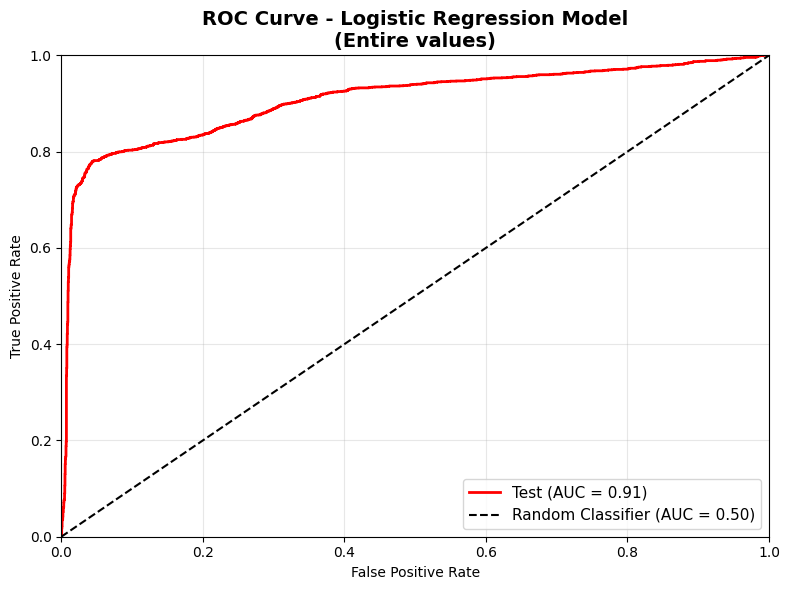

In [296]:
# Business and Workflow 
h.plot_reg_results(y_test, y_test_proba, "Entire values")

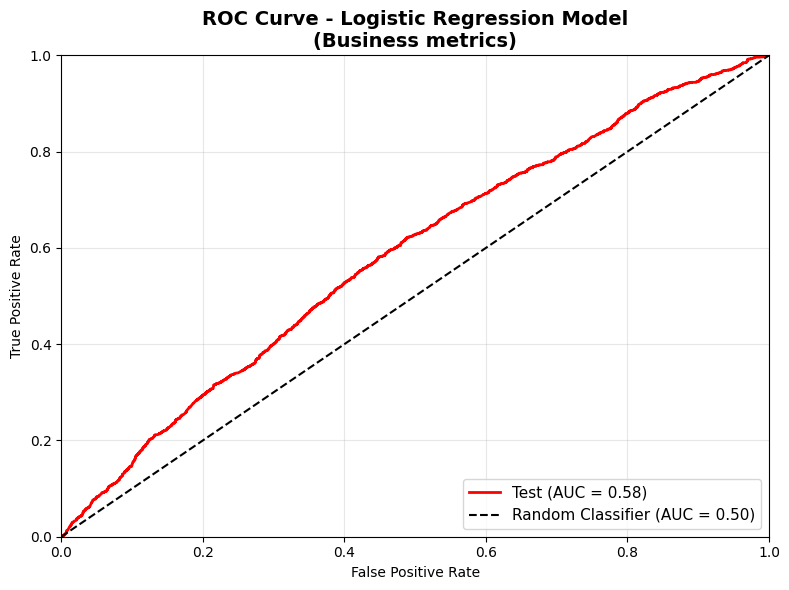

In [297]:
h.plot_reg_results(y_test_b, y_test_proba_b, "Business metrics")

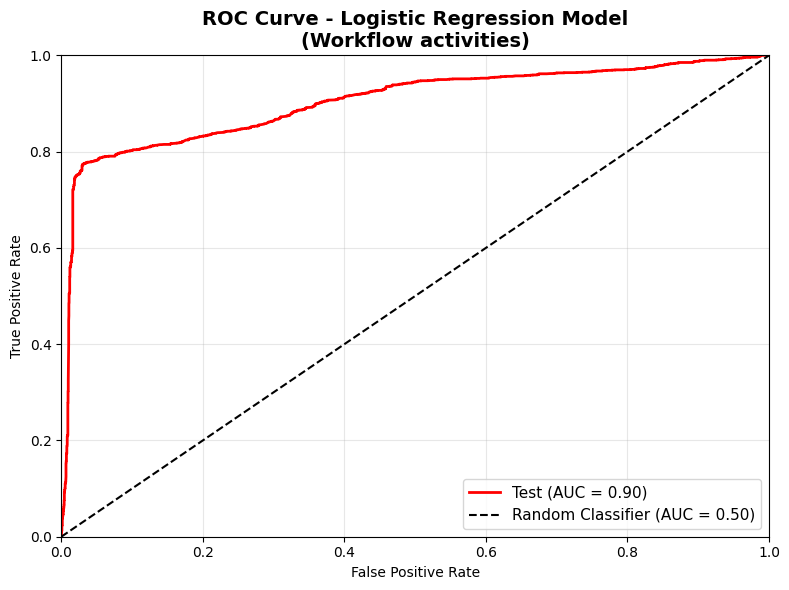

In [298]:
h.plot_reg_results(y_test_w, y_test_proba_w, "Workflow activities")